In [32]:
%load_ext autoreload
%autoreload 2

import sys, os
sys.path.append(os.path.dirname(os.path.dirname(os.getcwd())))
os.environ['PYTHONPATH'] = ':'.join(sys.path)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [33]:
import numpy as np
import hgpflow_v2.performance # don't know why this is needed, but it is
from hgpflow_v2.performance.performance import PerformanceCOCOA
from copy import deepcopy

## Paper Dijet Samples

In [34]:
from hgpflow_v2.performance.performance import PerformanceCOCOA
from hgpflow_v2.performance.plot_helper_event import compute_jet_residual_dict, plot_jet_residuals

RUN = '/pscratch/sd/a/agolub/hgpflow_runs/hgpflow_v2/largeqqbartraining4nodev1epoch25'

perf = PerformanceCOCOA(
    truth_path='/pscratch/sd/a/agolub/hgpflow_paper_files/dijet_test.root',  # raw COCOA file
    pred_path=f'{RUN}/inference/dijet_test/pred_*_merged.root',              # your 36 chunk preds
    ind_threshold=0.4)


Computing HGPFlow mass...: 100%|██████████| 35696/35696 [00:01<00:00, 31805.96it/s]


E, pT will be scaled by 0.001


Applying fiducial cuts...: 100%|██████████| 35696/35696 [00:00<00:00, 66177.98it/s]


common event count: 35696


Filtering and reordering HGPFlow...: 100%|██████████| 12/12 [00:00<00:00, 699.70it/s]


In [35]:
perf.compute_jets(radius=0.4, algo='antikt')   # anti-kT R=0.4, as in the paper
perf.match_jets()                              # Hungarian ΔR matching, truth vs reco

residual_dict = compute_jet_residual_dict({
    'HGPflow': perf.hgpflow_dict['matched_hgpflow_jets'],
    'PPflow' : perf.truth_dict['matched_ppflow_jets'],   # parametric baseline, from the truth file
})

Jet clustering algorithm:  antikt
Jet clustering radius:  0.4
truth


Computing jets...: 100%|██████████| 35696/35696 [02:52<00:00, 207.43it/s]


ppflow


Computing jets...: 100%|██████████| 35696/35696 [06:28<00:00, 91.94it/s] 


proxy


Computing jets...: 100%|██████████| 35696/35696 [03:54<00:00, 151.94it/s]


hgpflow


Matching jets...: 100%|██████████| 35696/35696 [00:01<00:00, 18775.29it/s]


In [36]:
import numpy as np
ts = np.array([x.sum() for x in perf.truth_dict['particle_pt']])
hs = np.array([x.sum() for x in perf.hgpflow_dict['hgpflow_pt']])
print('alignment corr:', np.corrcoef(ts, hs)[0,1].round(3))   # expect ~0.98

alignment corr: 0.982


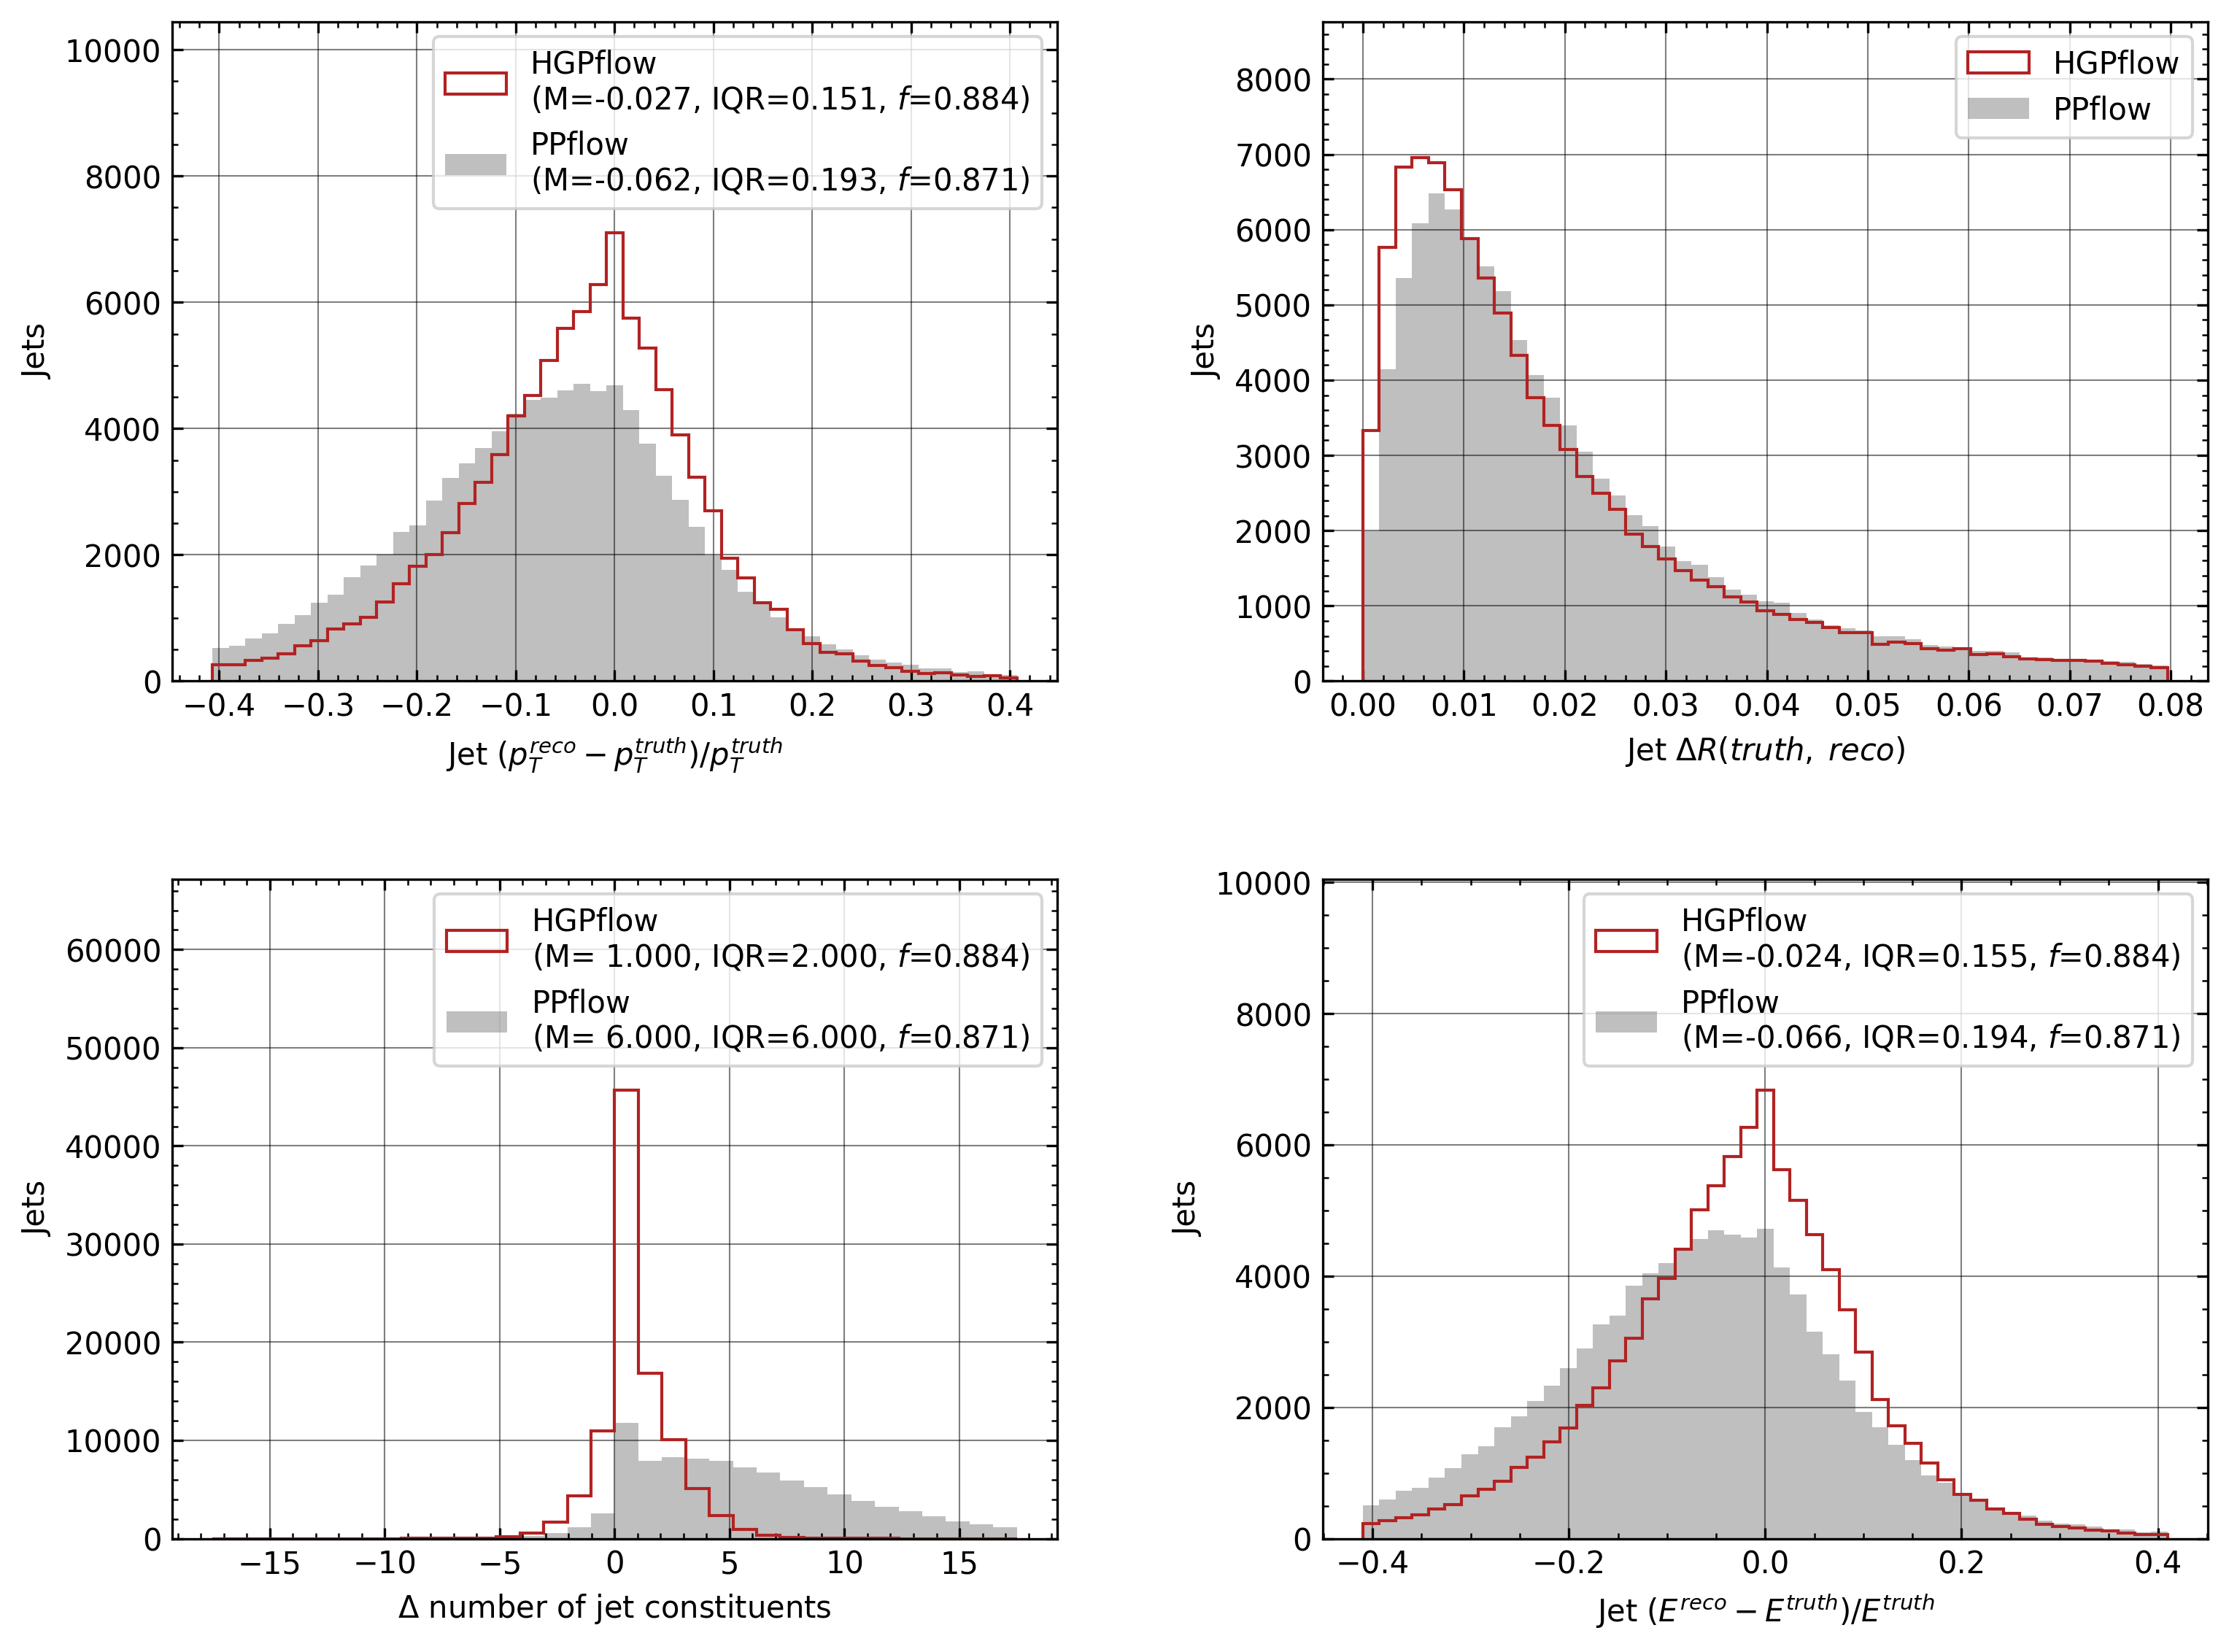

In [37]:
residual_dict = compute_jet_residual_dict({
    'hgpflow': perf.hgpflow_dict['matched_hgpflow_jets'],
    'ppflow' : perf.truth_dict['matched_ppflow_jets'],
})
fig = plot_jet_residuals(residual_dict, pt_relative=True)
fig.savefig('jet_matching_dijet_test.png', dpi=150, bbox_inches='tight')


In [38]:
perf.hgpflow_dict['hgpflow_eta'] = perf.hgpflow_dict['proxy_eta']
perf.hgpflow_dict['hgpflow_phi'] = perf.hgpflow_dict['proxy_phi']

for i in range(len(perf.hgpflow_dict['hgpflow_pt'])):
    ch_mask = perf.hgpflow_dict['hgpflow_class'][i] <= 2
    perf.hgpflow_dict['hgpflow_pt'][i][ch_mask] = perf.hgpflow_dict['proxy_pt'][i][ch_mask]

In [39]:
perf.compute_jets(n_procs=30)
perf.match_jets()

Jet clustering algorithm:  antikt
Jet clustering radius:  0.4
truth
ppflow
proxy
hgpflow


Matching jets...: 100%|██████████| 35696/35696 [00:01<00:00, 32746.11it/s]


### Jet residual plots

In [40]:
from hgpflow_v2.performance.plot_helper_event import compute_jet_residual_dict

_dict = {
    'ppflow': perf.truth_dict['matched_ppflow_jets'],
    'hgpflow': perf.hgpflow_dict['matched_hgpflow_jets'],
}

jet_residual_dict = compute_jet_residual_dict(_dict, dr_cut=0.1, leading_N_jets=2, pt_min=10)

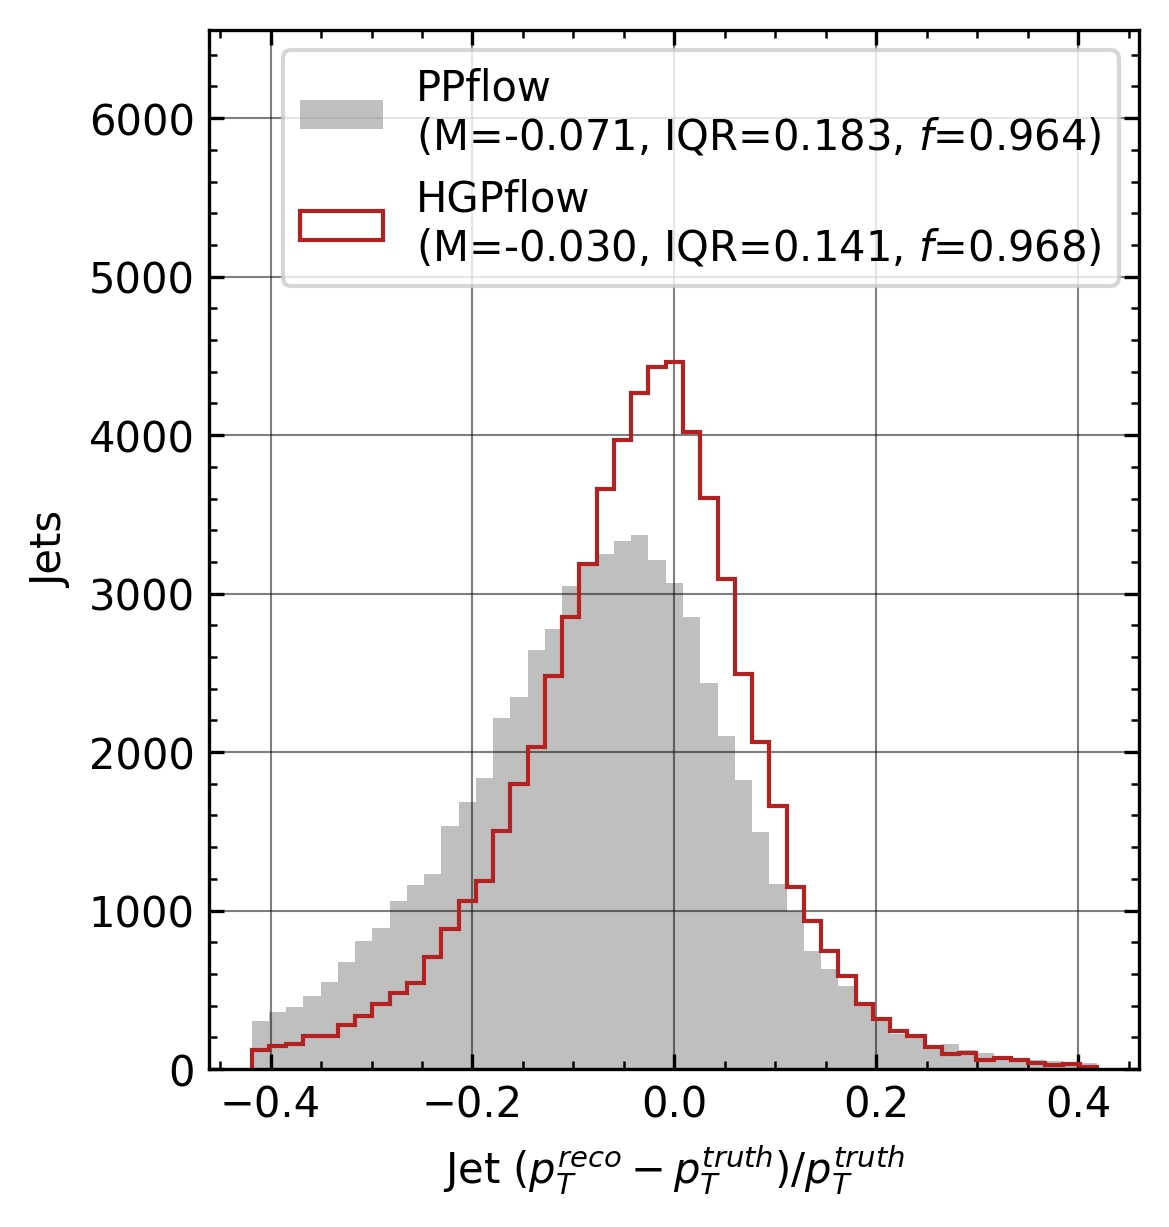

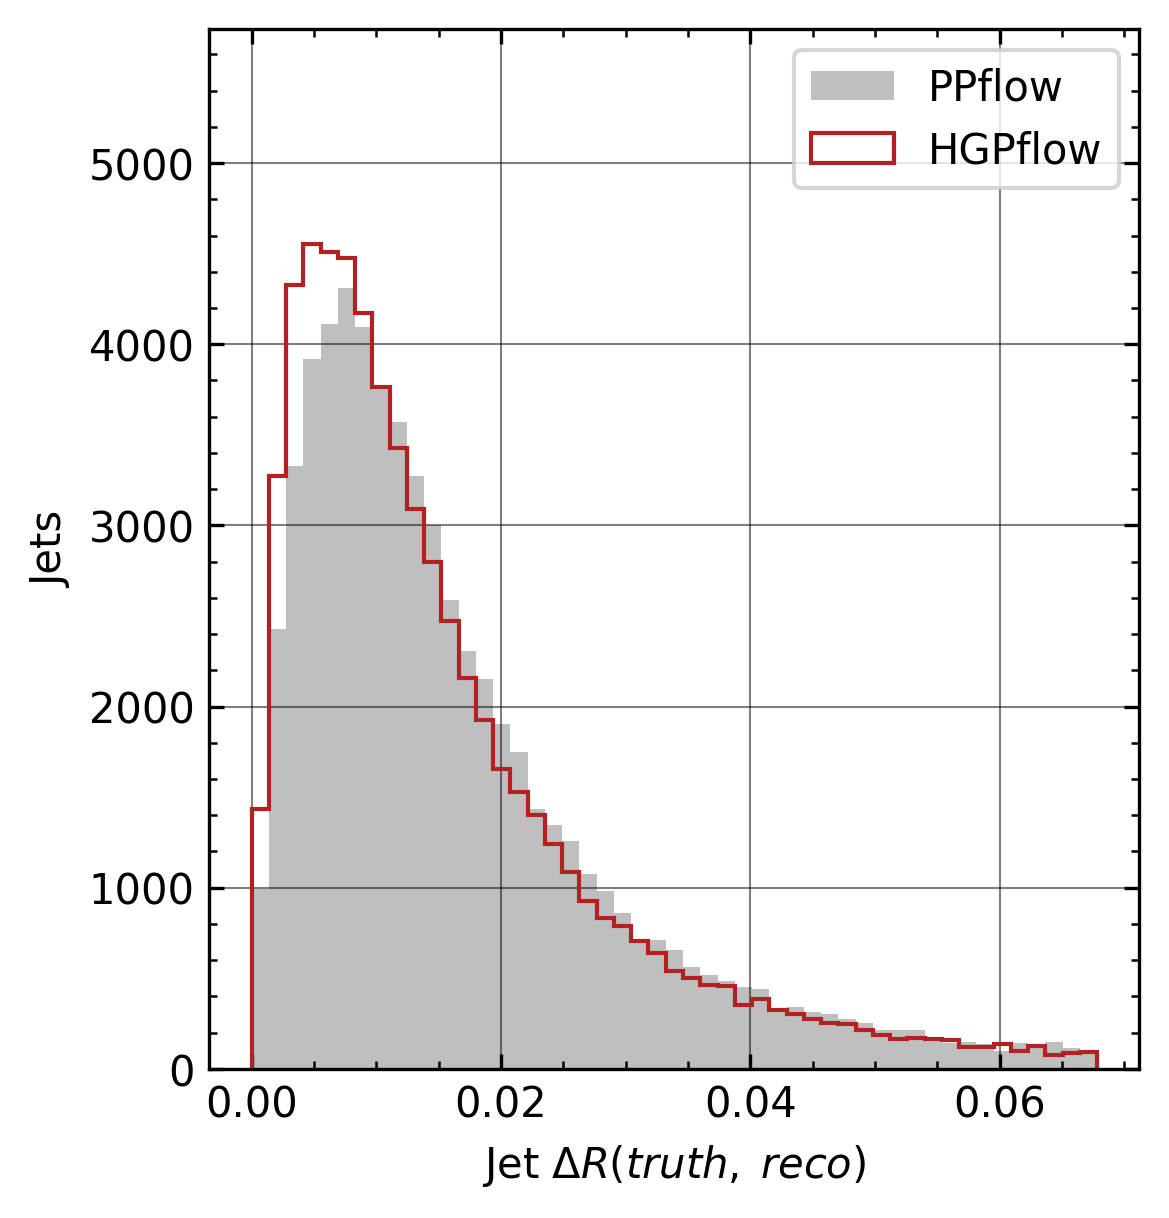

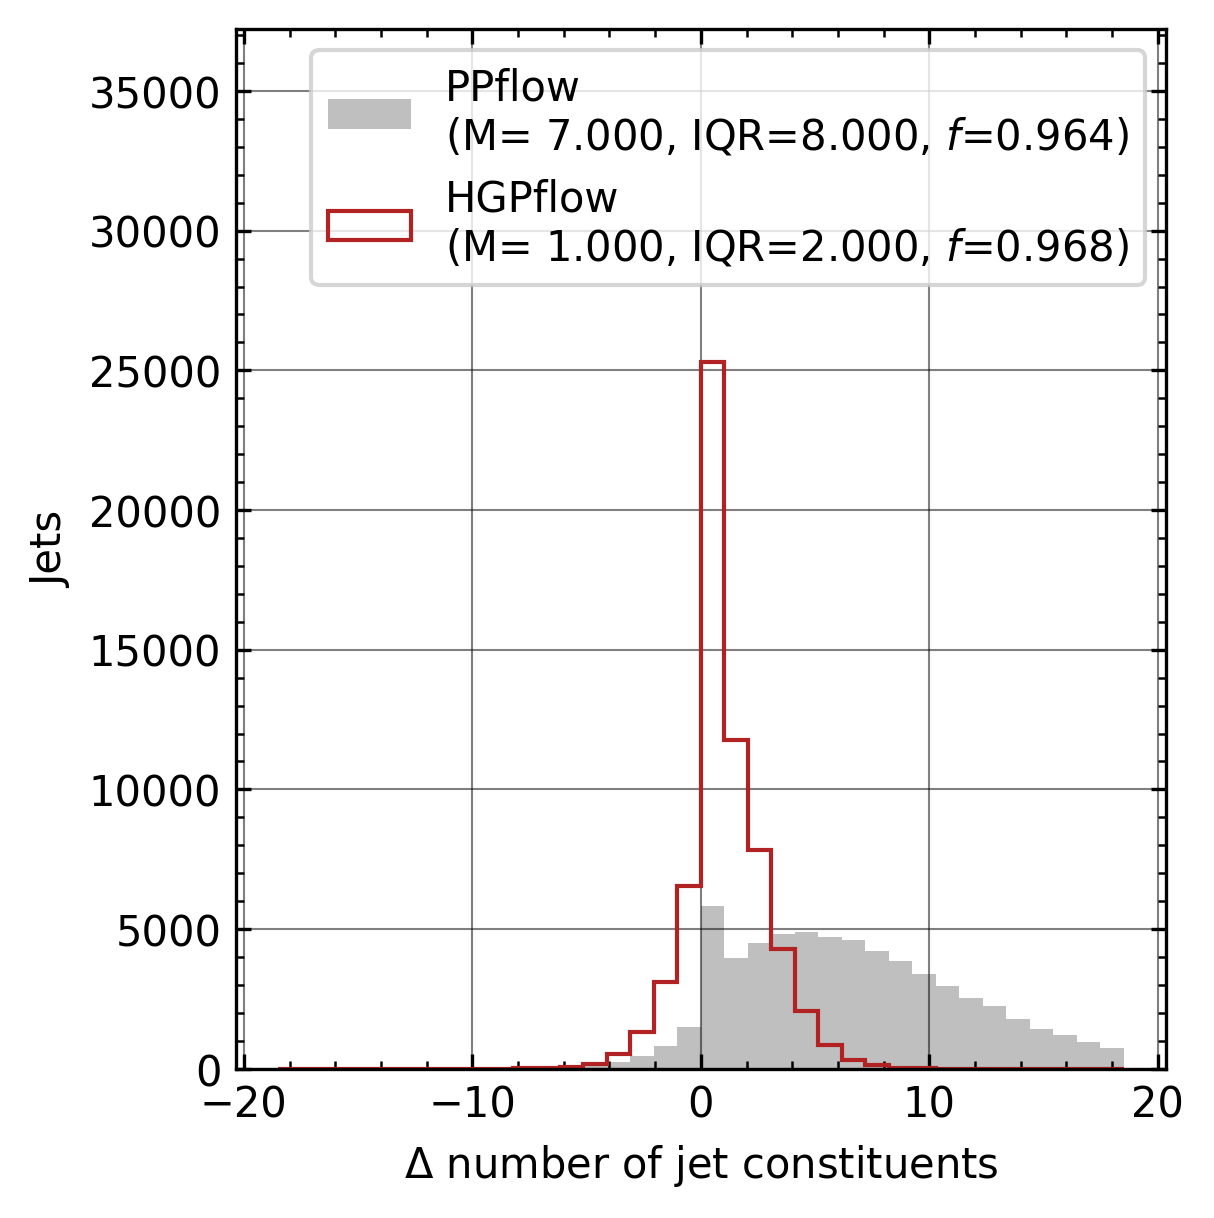

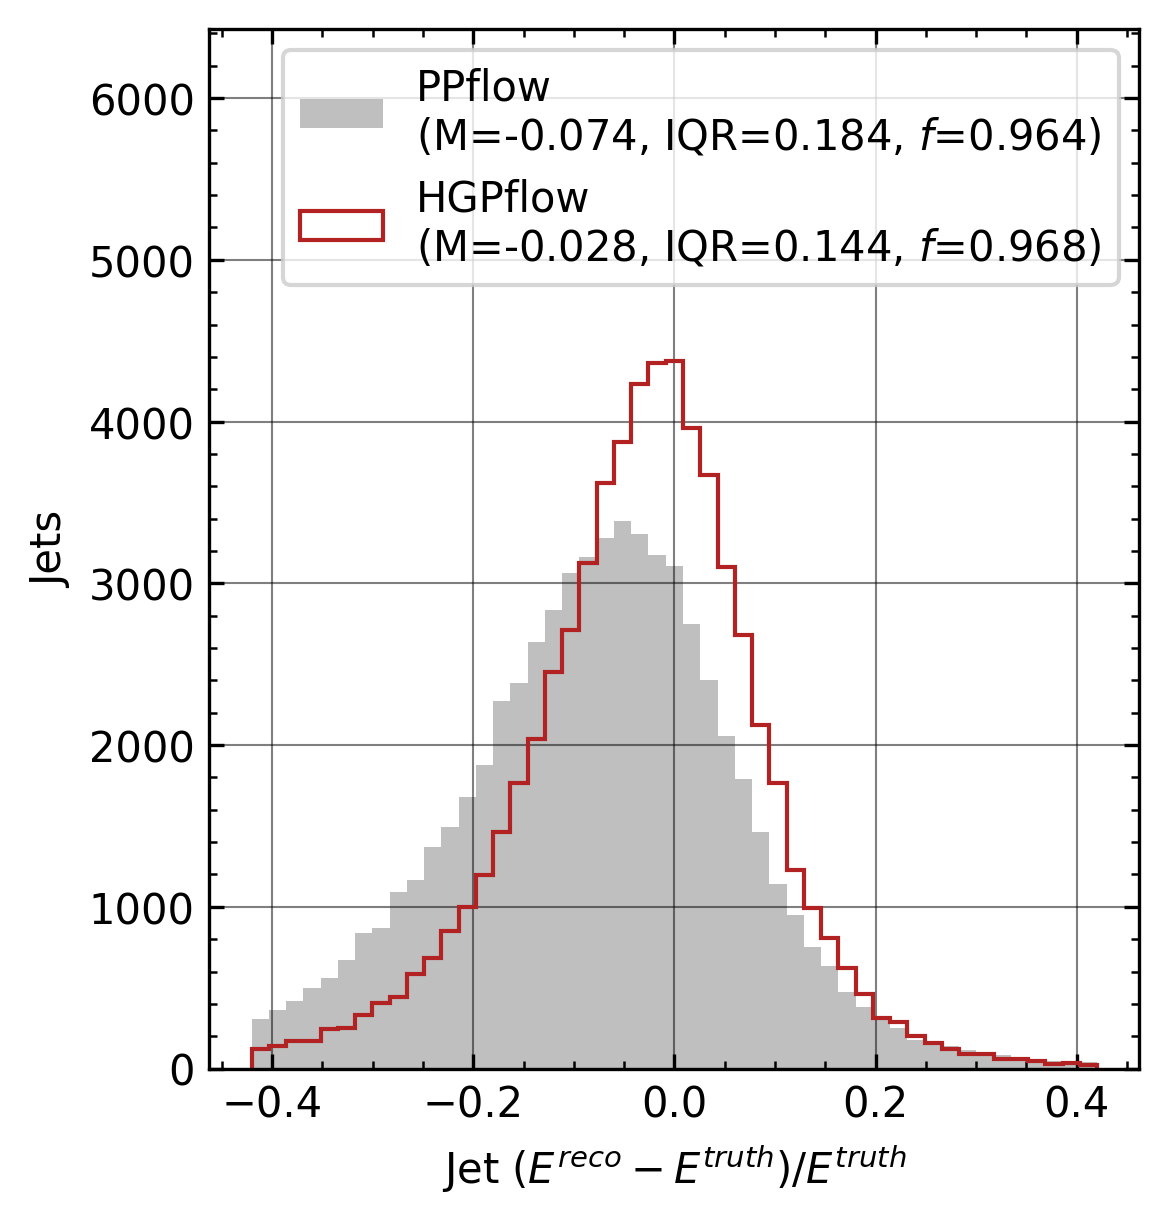

In [41]:
from hgpflow_v2.performance.plot_helper_event import plot_jet_residuals

figs = plot_jet_residuals(jet_residual_dict, pt_relative=True, separate_figures=True)

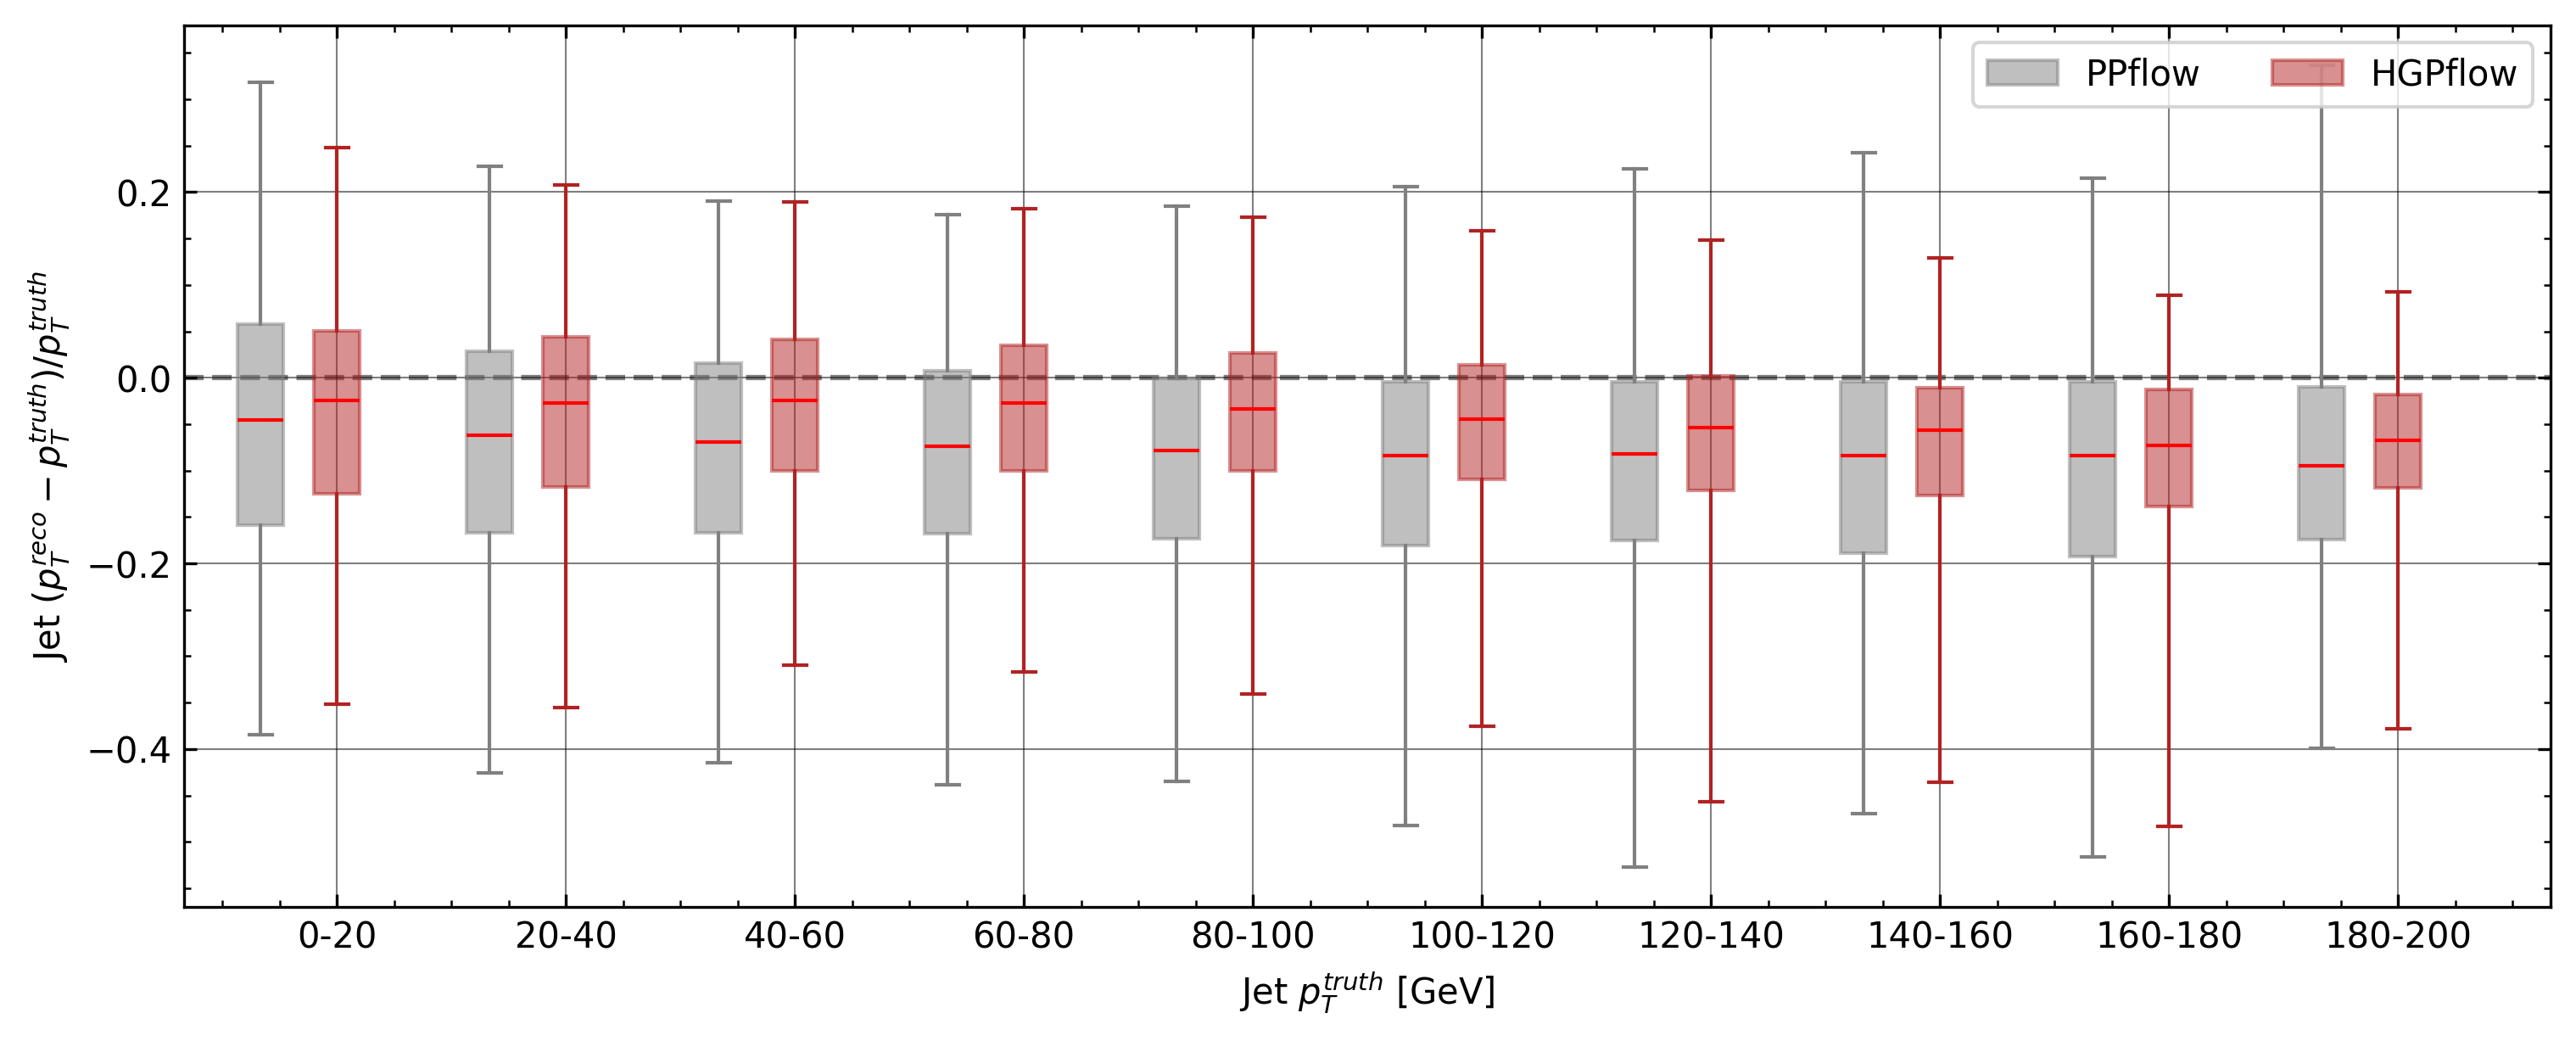

In [42]:
from hgpflow_v2.performance.plot_helper_event import plot_jet_res_boxplot

pt_bins = np.array([0, 20, 40, 60, 80, 100, 120, 140, 160, 180, 200])
fig = plot_jet_res_boxplot(jet_residual_dict, bins=pt_bins)

In [43]:
perf.hung_match_particles(flatten=True, return_unmatched=True)

Matching particles...: 100%|██████████| 35696/35696 [00:14<00:00, 2499.32it/s]


In [44]:
style_sheet_eff_fr = {
    'LINE_STYLES': {
        'hgpflow': '-',
        'ppflow': '--',
    },
    'COLORS': {
        'hgpflow': {
            'neut had': 'mediumseagreen',
            'photon': 'tomato',
        },
        'ppflow':{
            'neut nad' : 'dodgerblue',
            'photon' : 'goldenrod',
        }
    }
}

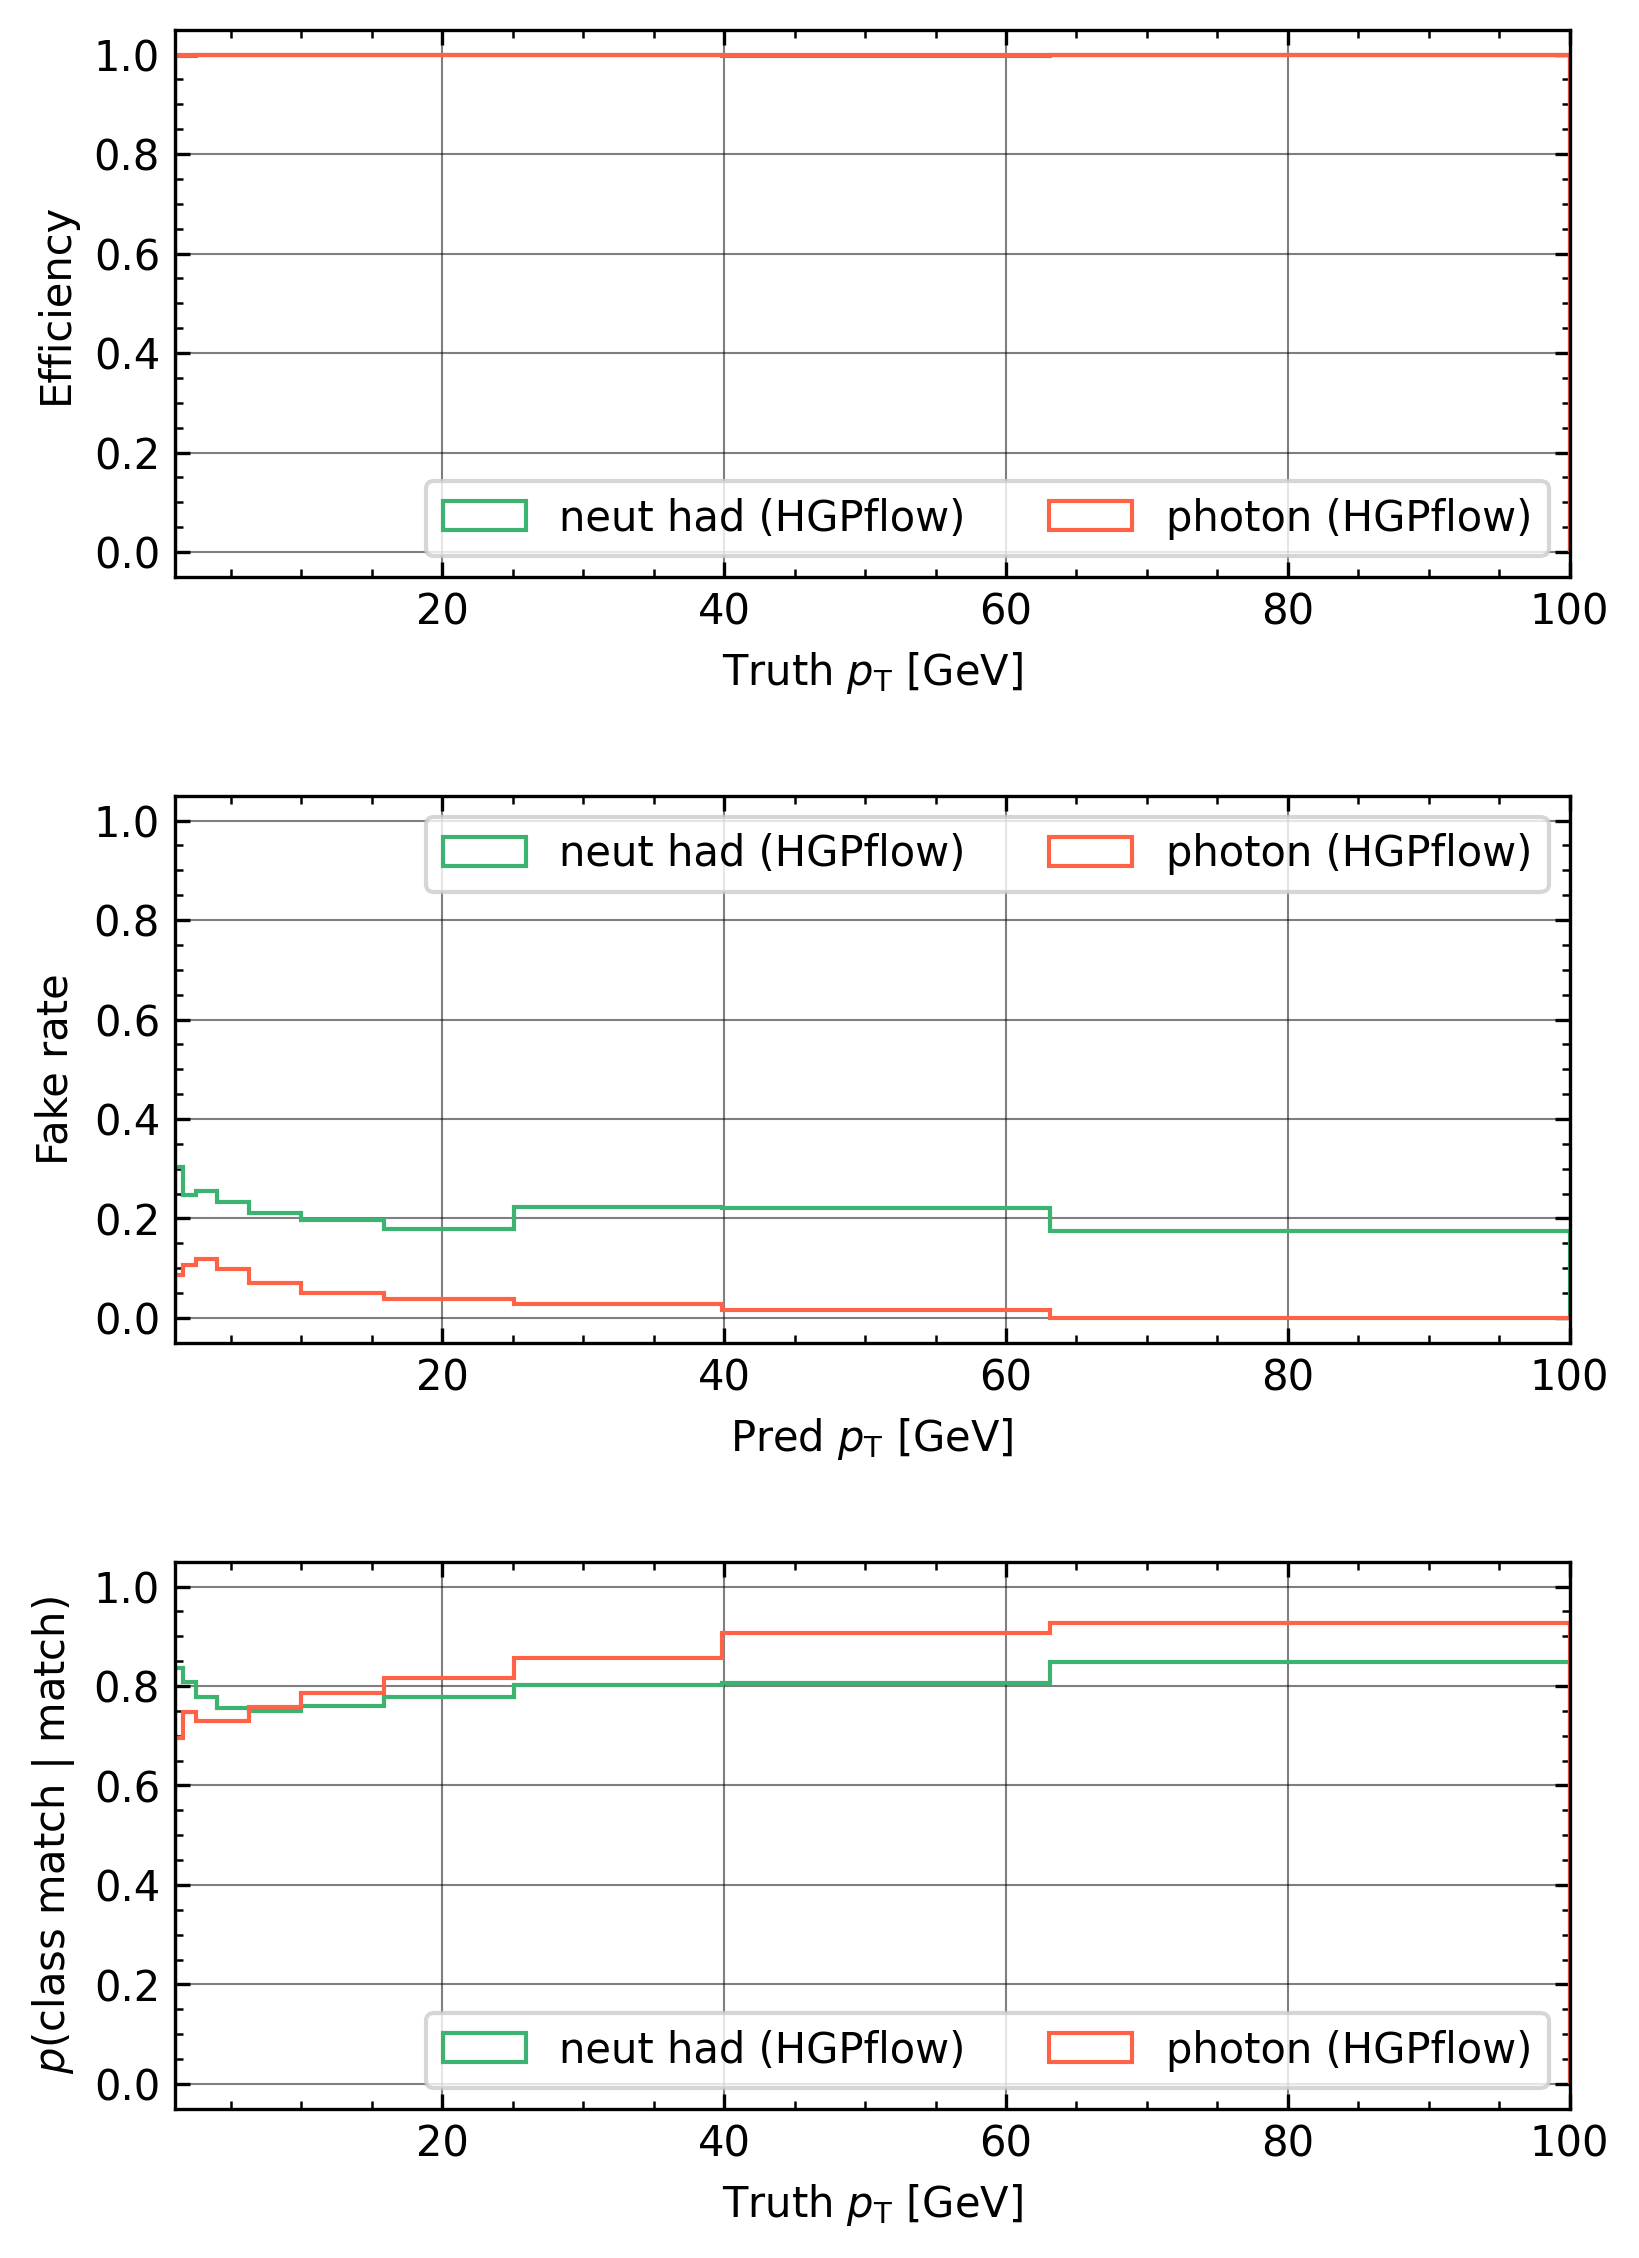

In [45]:
from hgpflow_v2.performance.plot_helper_particle import plot_eff_fr_purity

eff_fr_purity_input_dict = {
    'hgpflow': {
        'ref_matched': perf.hgpflow_dict['matched_hgpflow_particles'][0],
        'comp_matched': perf.hgpflow_dict['matched_hgpflow_particles'][1],
        'ref_unmatched': perf.hgpflow_dict['matched_hgpflow_particles'][2],
        'comp_unmatched': perf.hgpflow_dict['matched_hgpflow_particles'][3],
    },
}

fig = plot_eff_fr_purity(eff_fr_purity_input_dict, stylesheet=style_sheet_eff_fr)


(<Figure size 1200x1350 with 1 Axes>, <Figure size 1200x1350 with 1 Axes>)

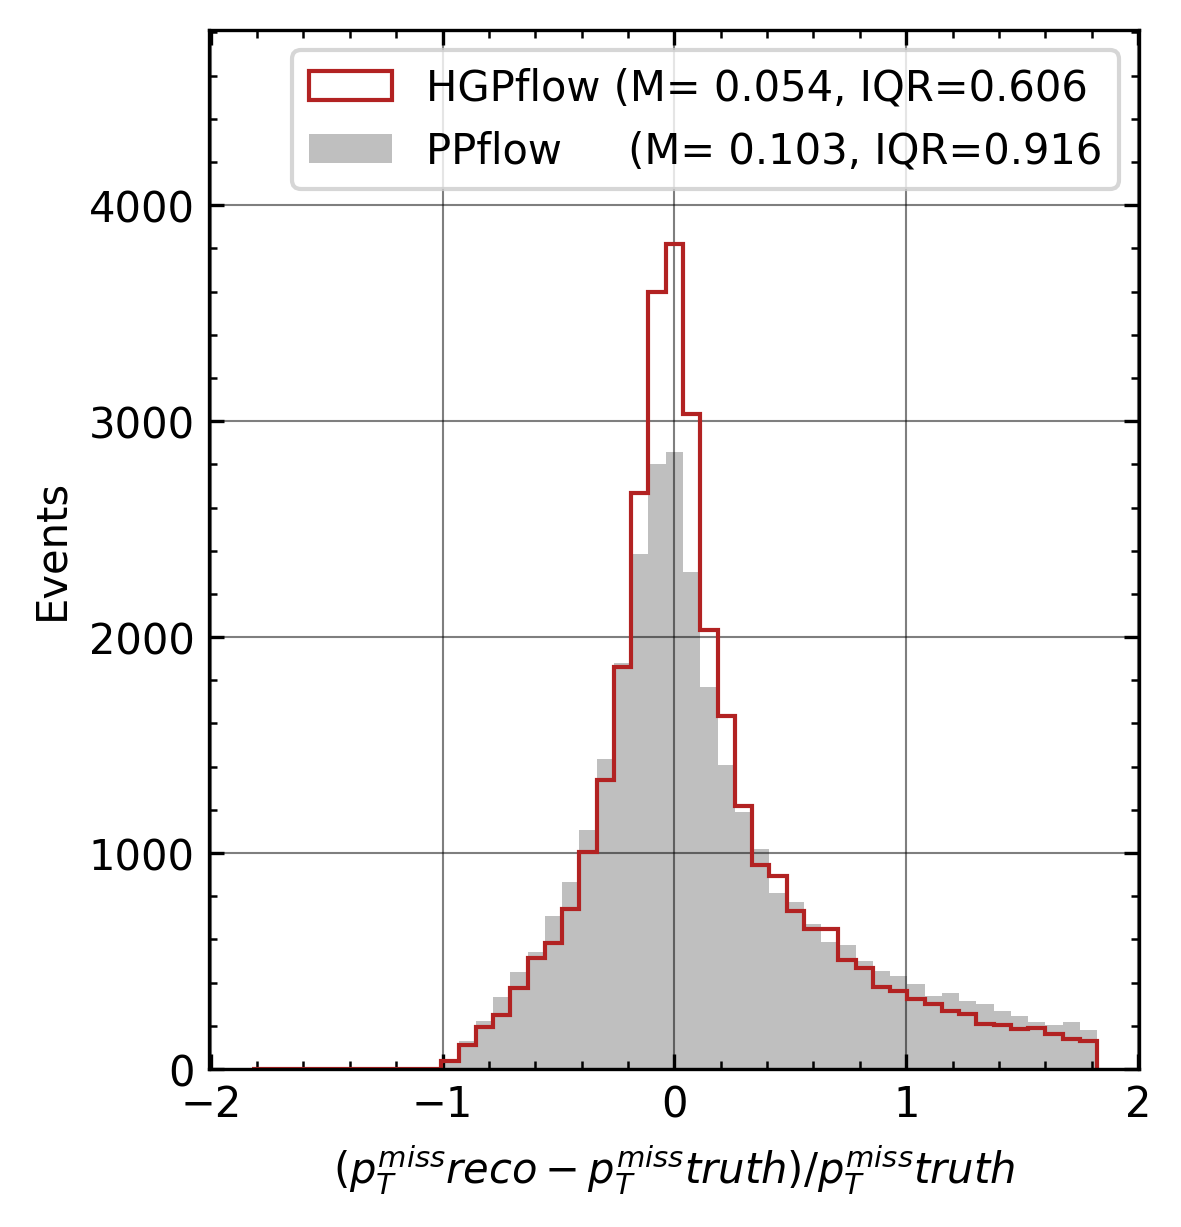

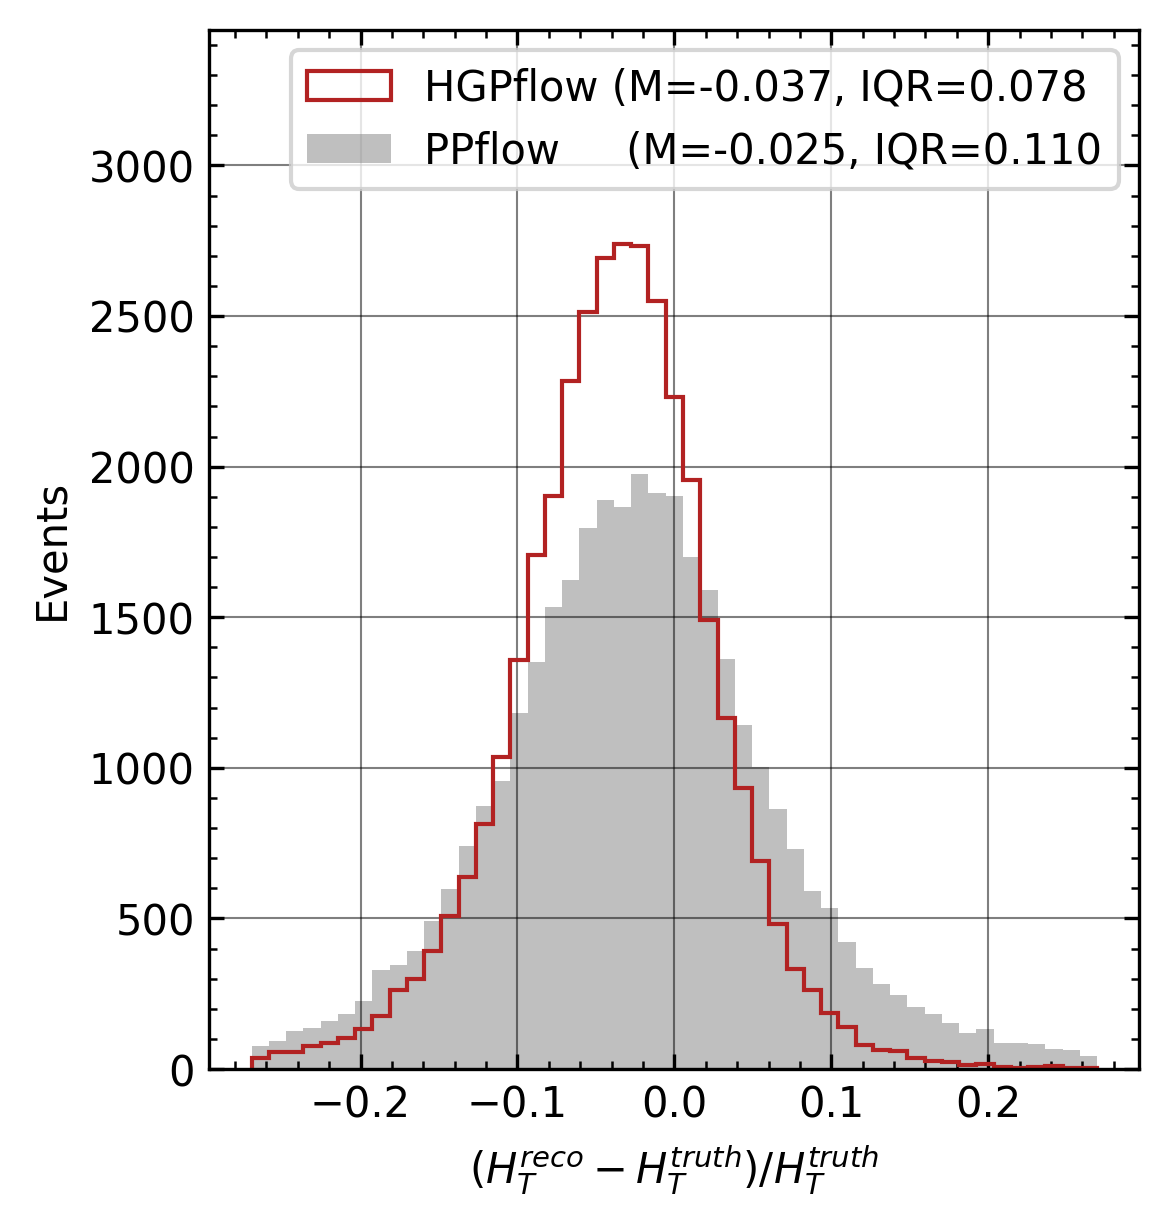

In [46]:
from hgpflow_v2.performance.plot_helper_event import plot_met_res_and_ht_res

met_res_and_ht_res_input_dict = {
    'hgpflow': [perf.hgpflow_dict['hgpflow_pt'], perf.hgpflow_dict['hgpflow_phi']],

    'ppflow': [perf.truth_dict['pflow_pt'], perf.truth_dict['pflow_phi']],
}
plot_met_res_and_ht_res(perf.truth_dict['particle_pt'], perf.truth_dict['particle_phi'], met_res_and_ht_res_input_dict)

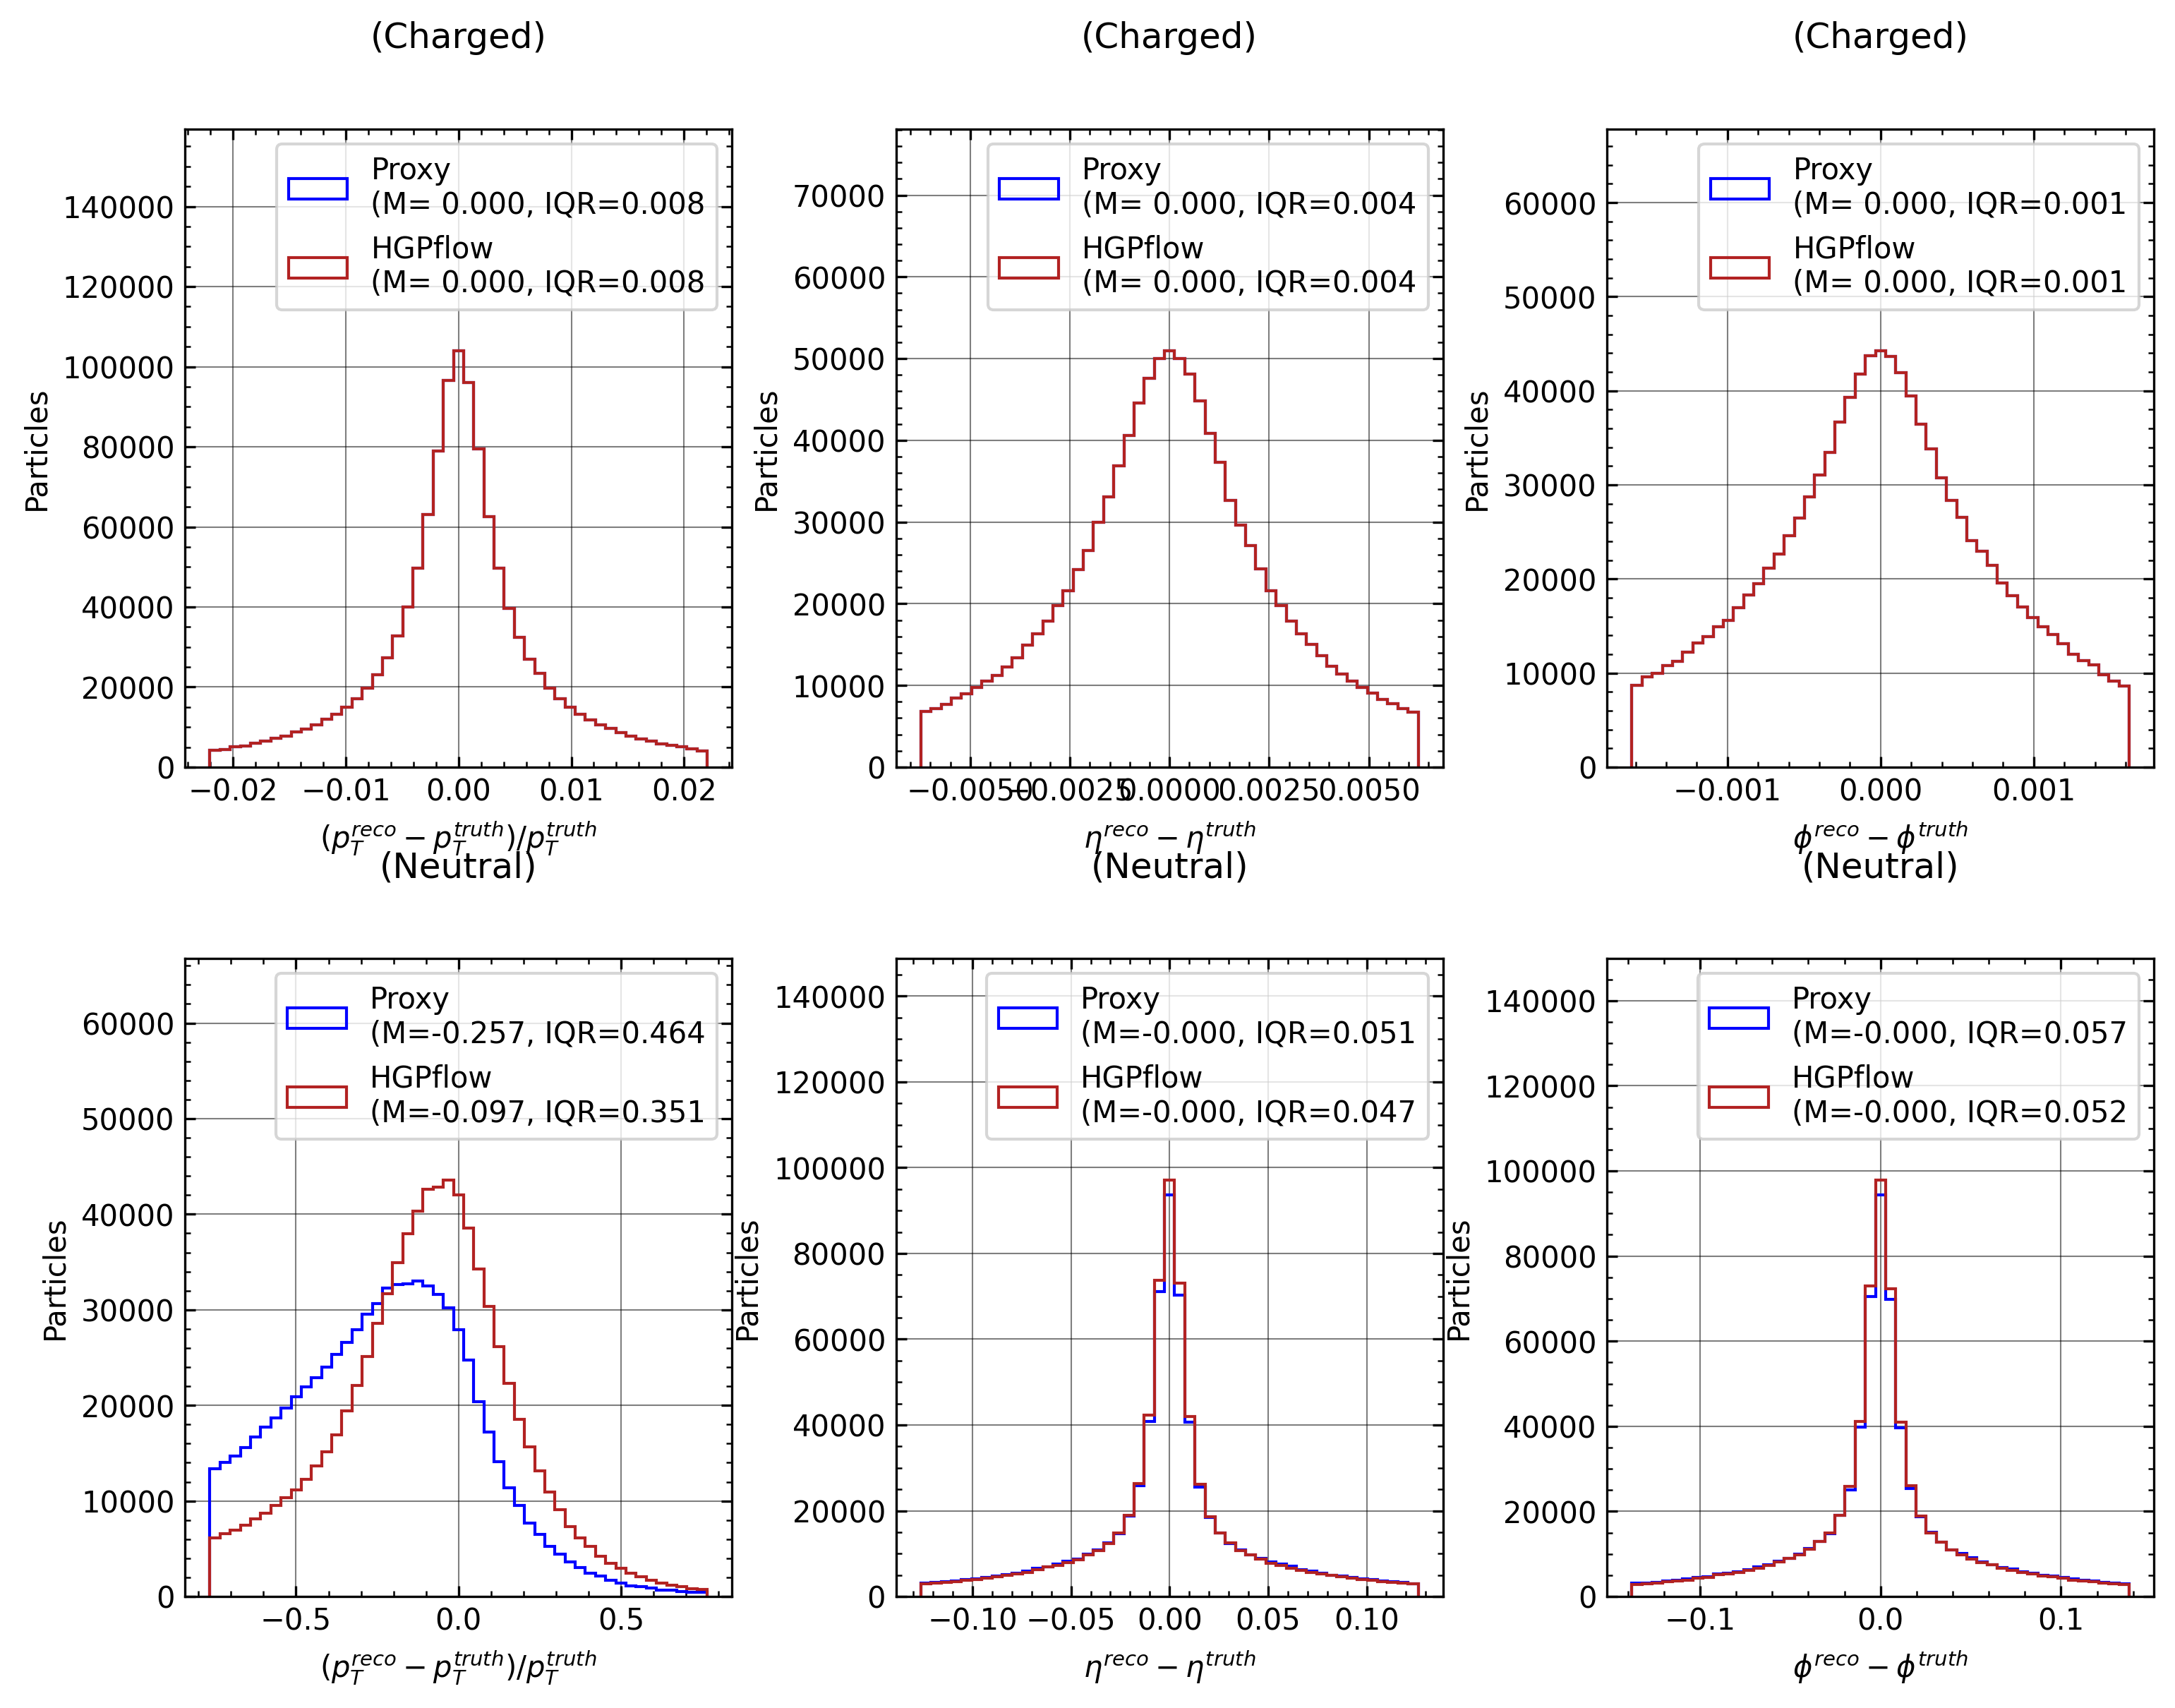

In [47]:
from hgpflow_v2.performance.plot_helper_particle import plot_residuals

# style_sheet_part_res = deepcopy(style_sheet)
# style_sheet_part_res['COLORS']['proxy'] = 'dodgerblue'
# style_sheet_part_res['LINE_STYLES']['proxy'] = '-'

_dict = {
    'proxy': perf.hgpflow_dict['matched_proxy_particles'],
    'hgpflow': perf.hgpflow_dict['matched_hgpflow_particles'],
}

qs = {
    'Charged': {'pt': 90, 'eta': 80, 'phi': 80}, 
    'Neutral': {'pt': 90, 'eta': 80, 'phi': 80}
}
fig = plot_residuals(_dict, pt_relative=True, log_y=False, qs=qs)

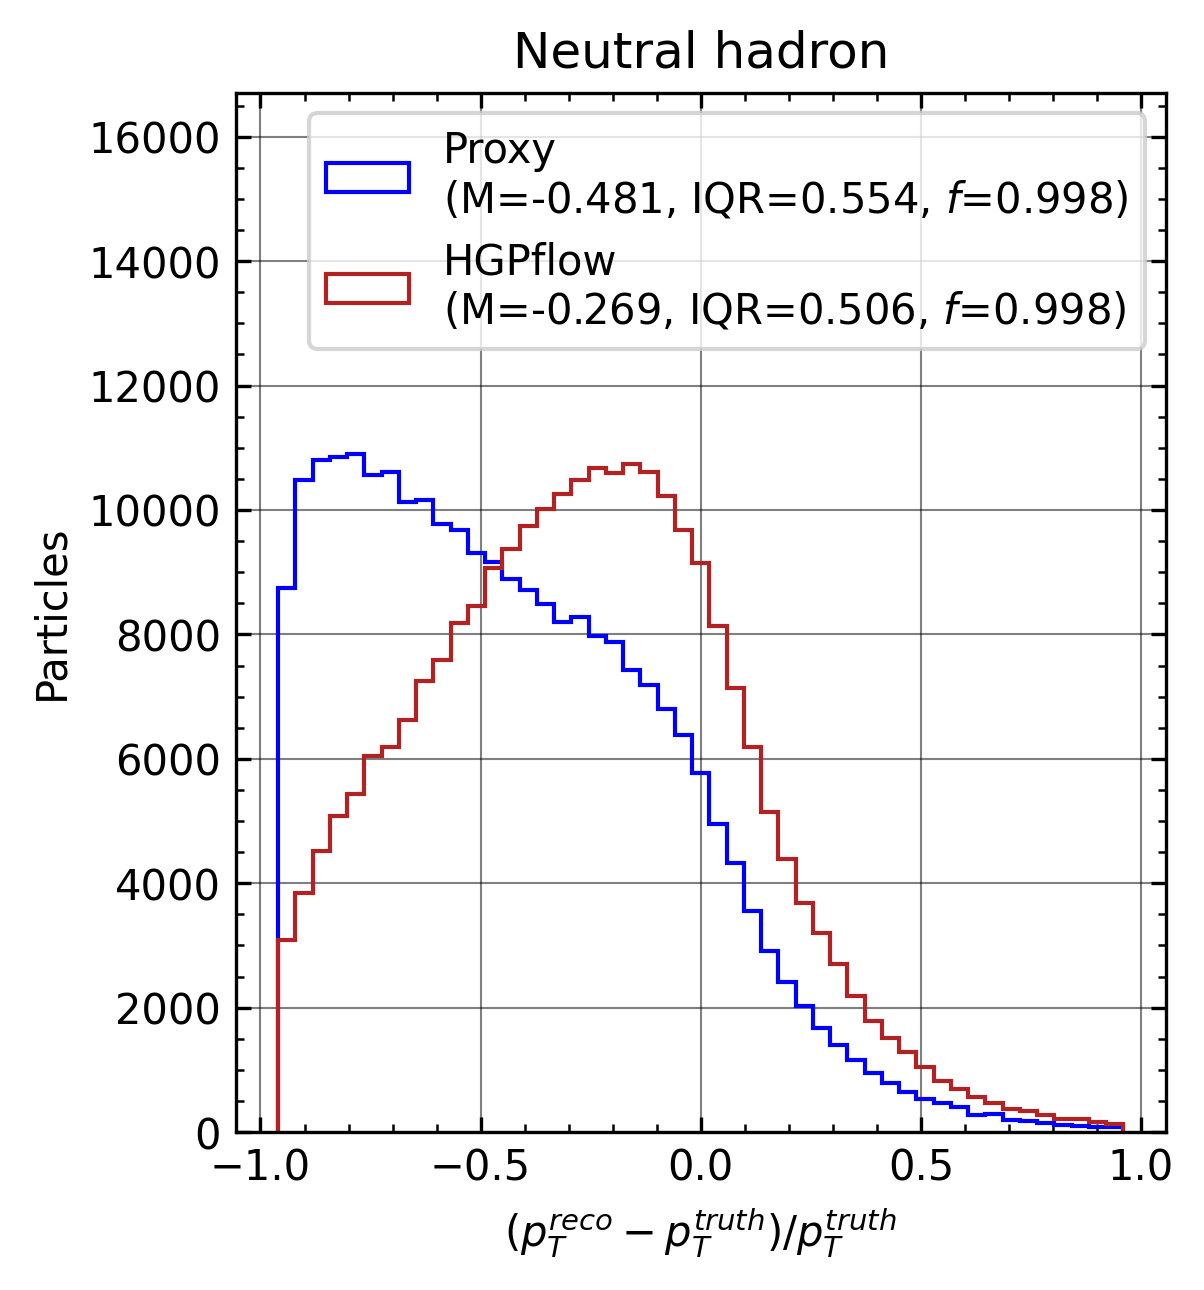

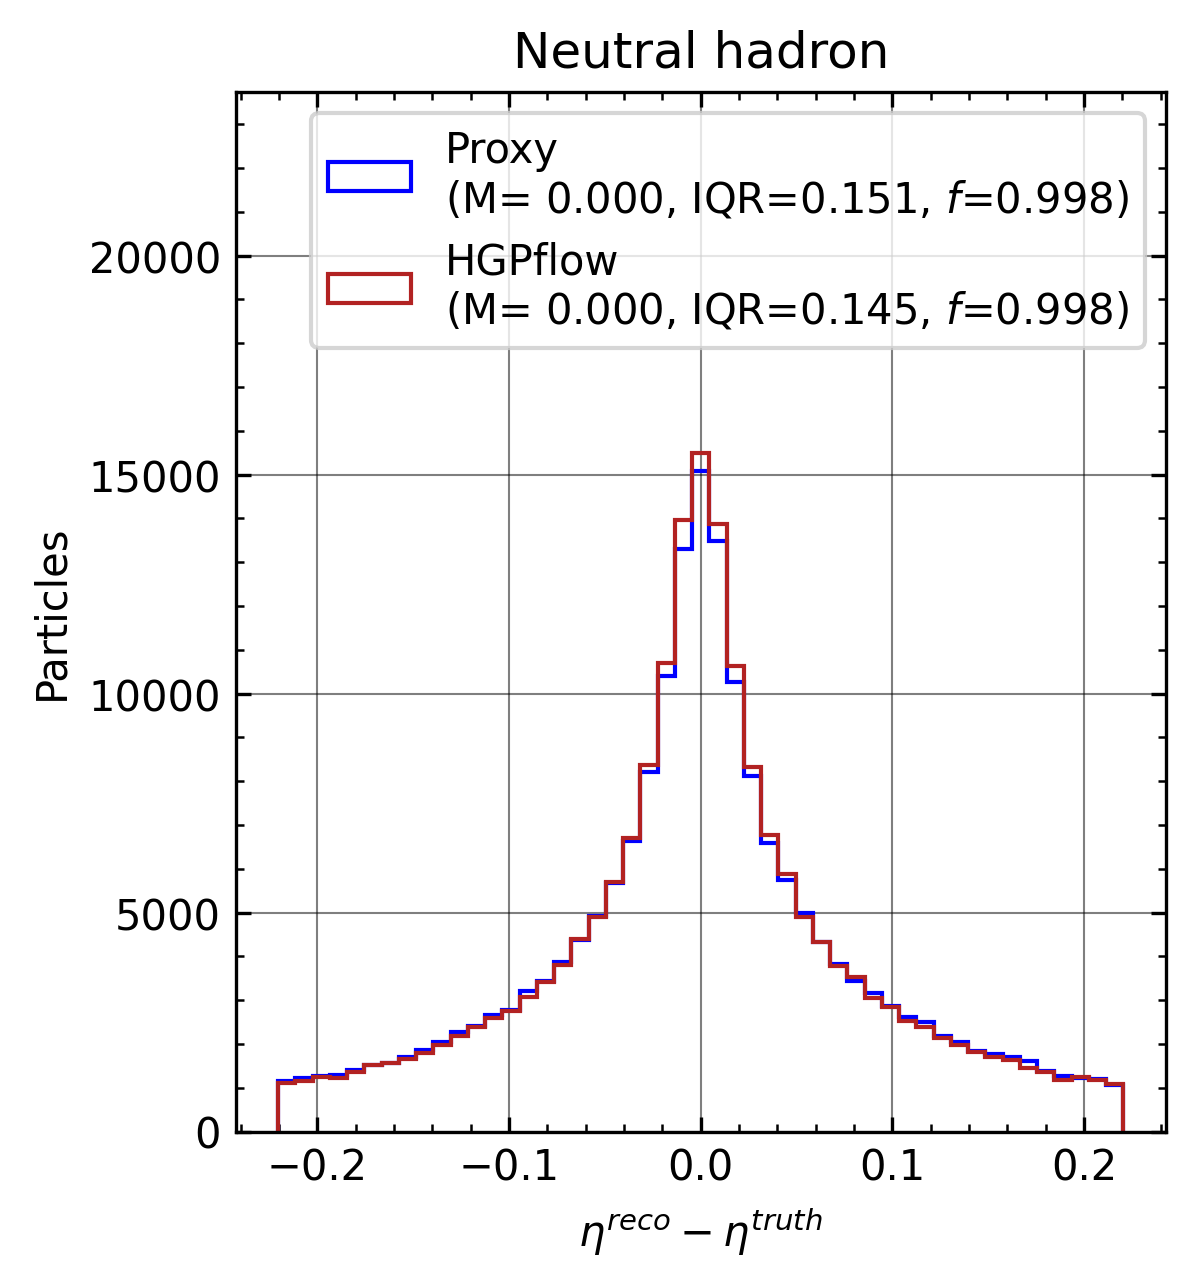

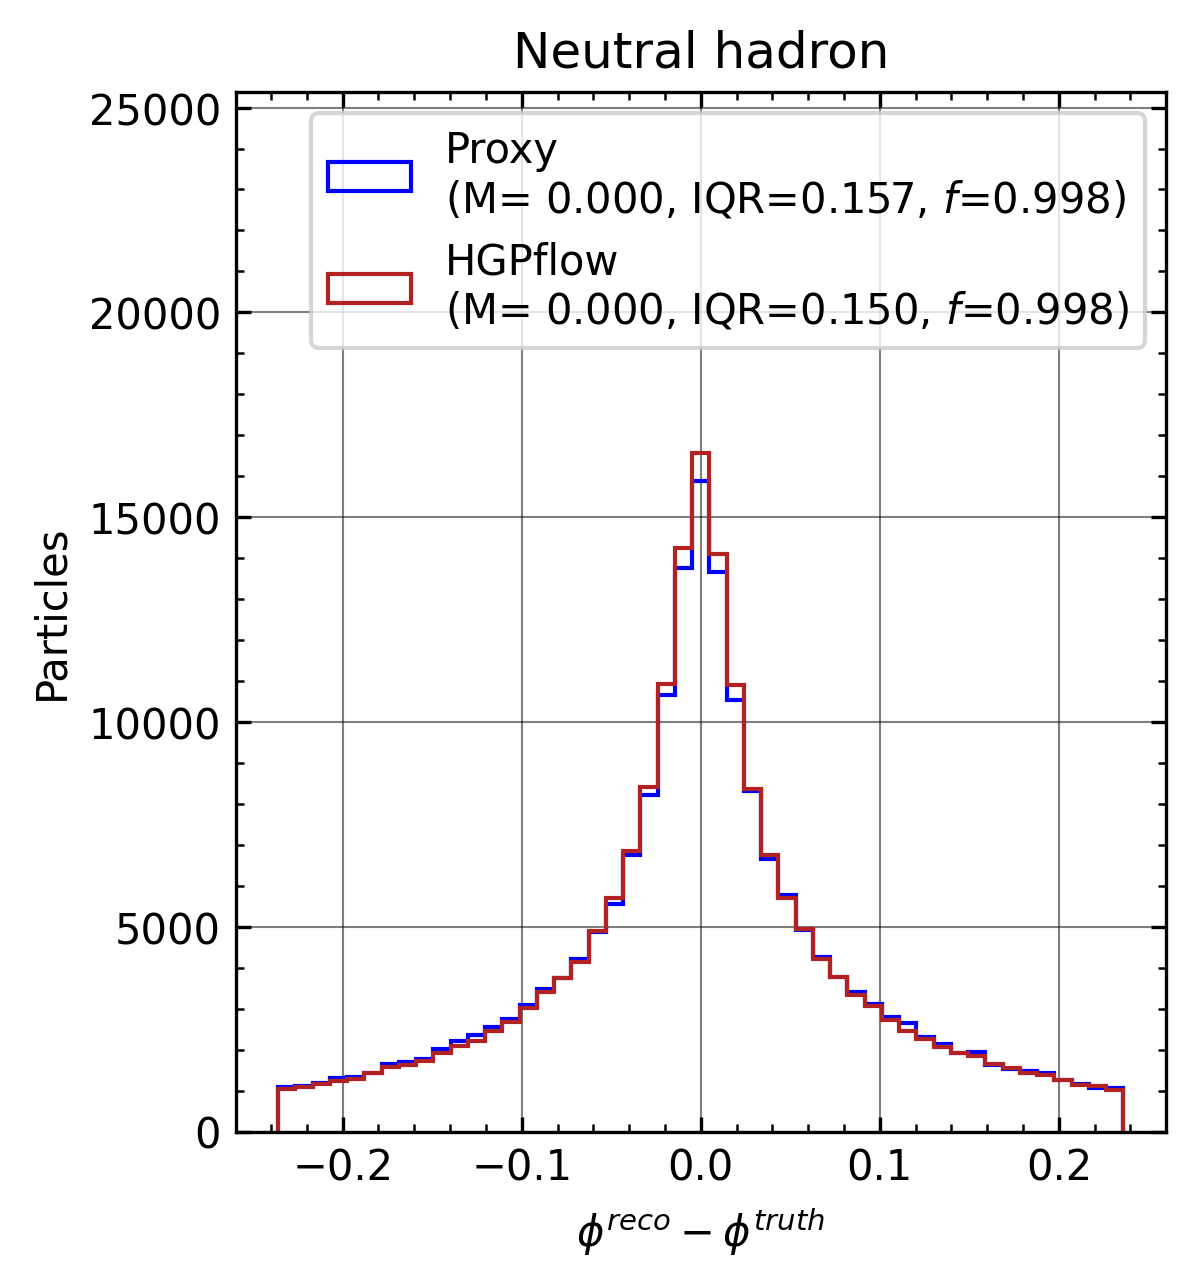

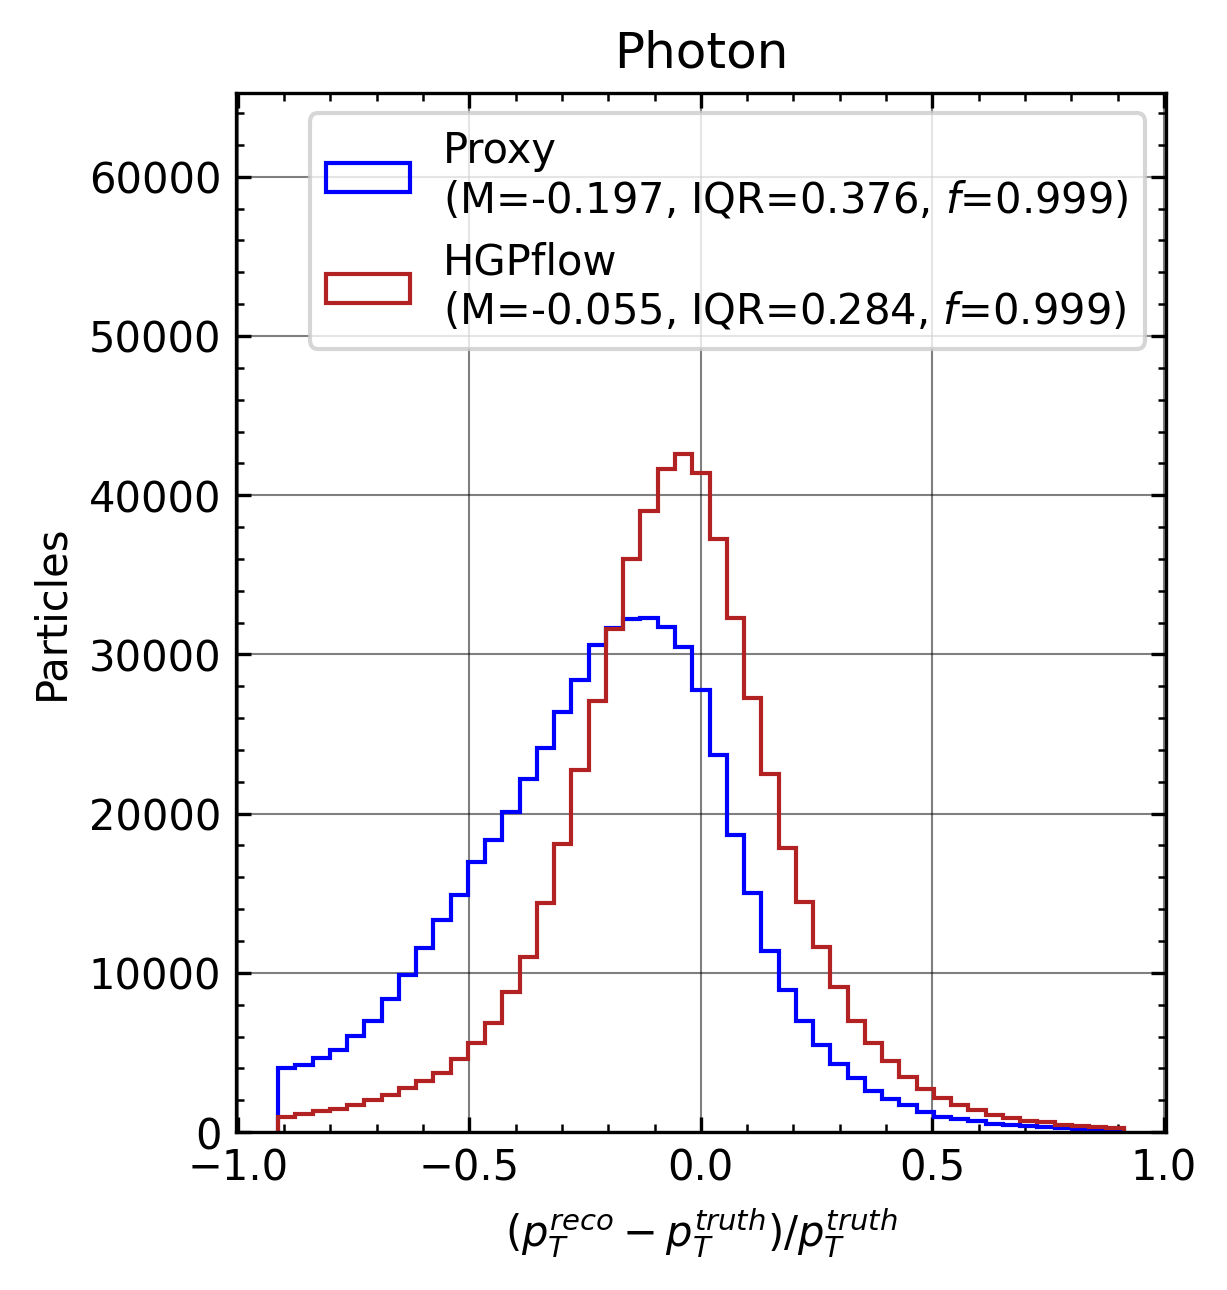

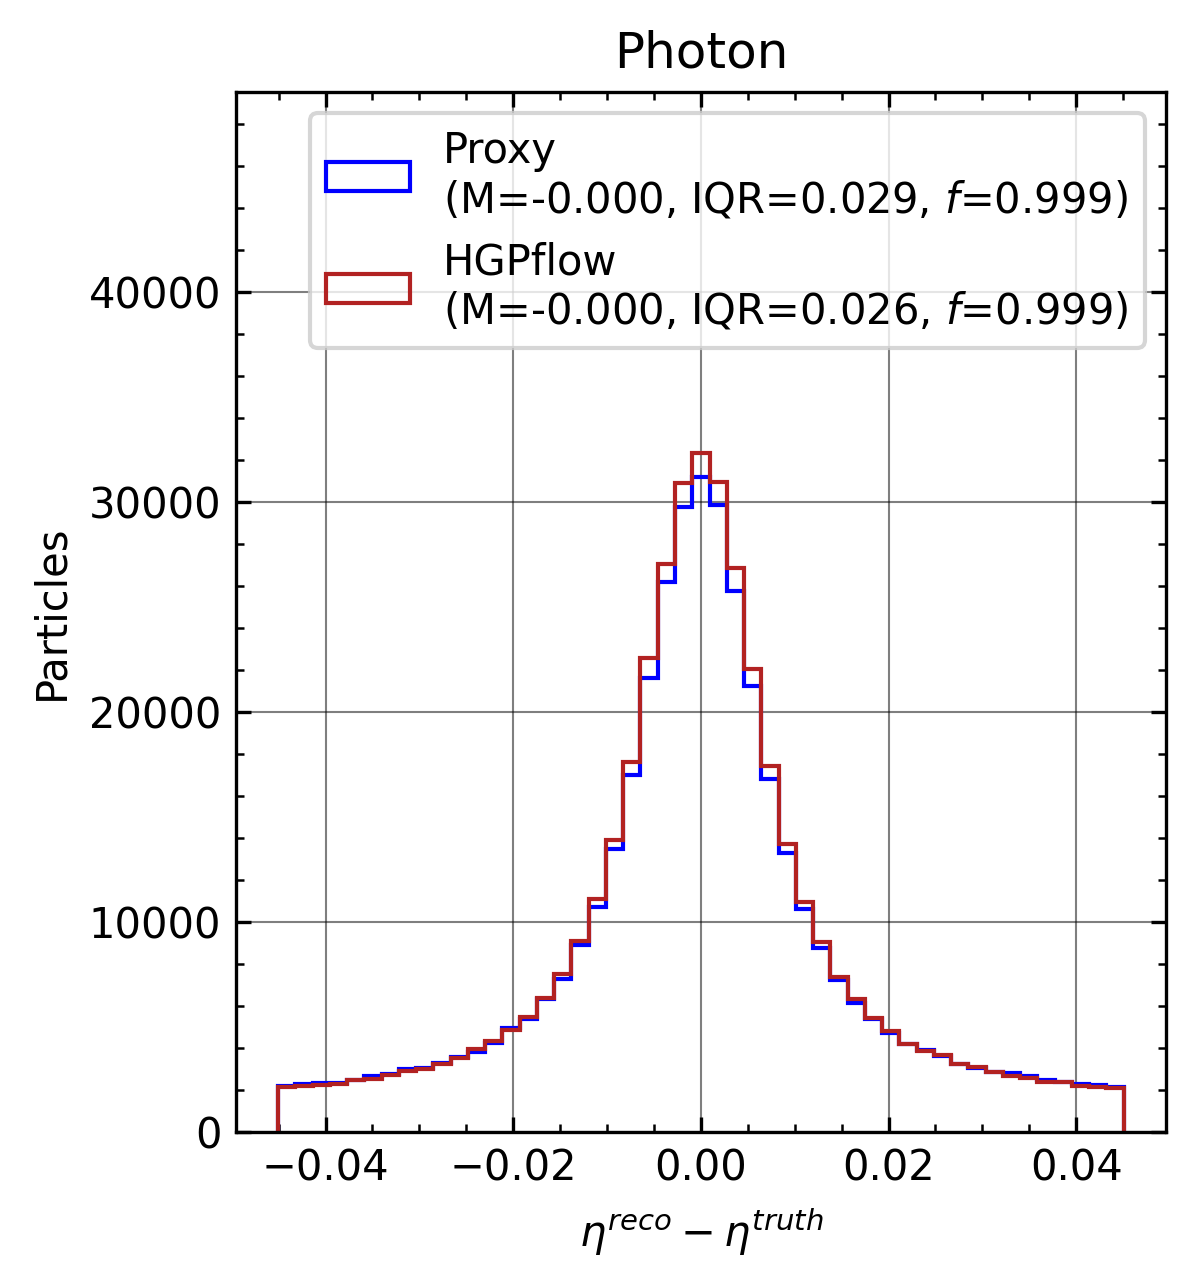

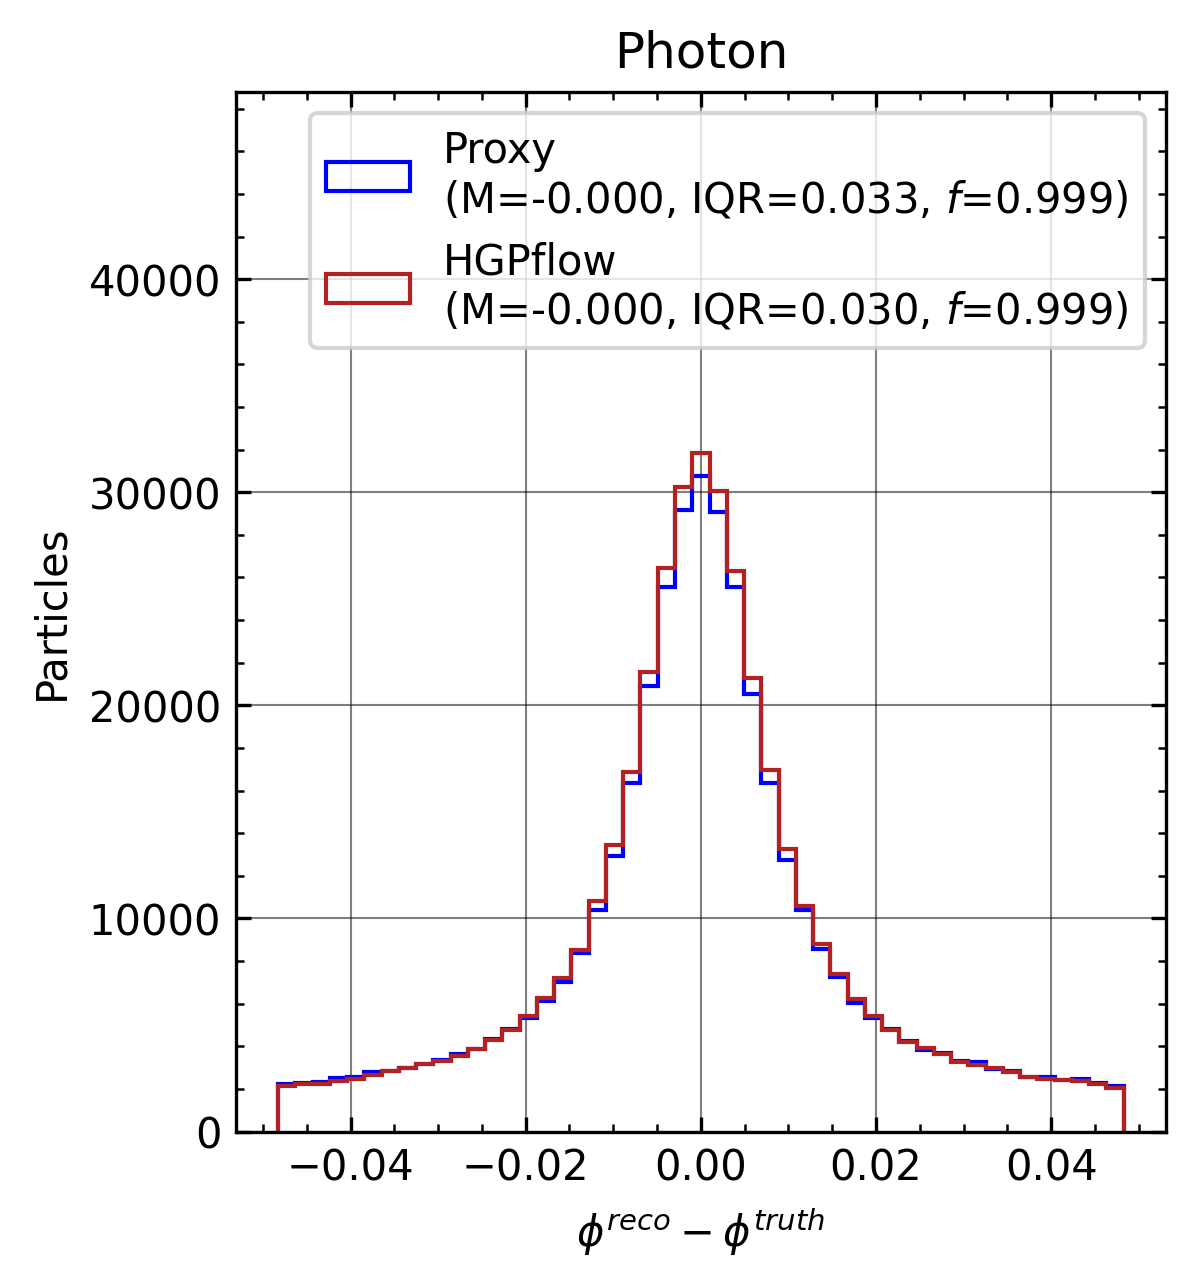

In [48]:
from hgpflow_v2.performance.plot_helper_particle import plot_residuals_neutrals

_dict = {
    'proxy': perf.hgpflow_dict['matched_proxy_particles'],
    'hgpflow': perf.hgpflow_dict['matched_hgpflow_particles'],
}

qs = {
    'Neutral hadron': {'pt': 98, 'eta': 75, 'phi': 75}, 
    'Photon': {'pt': 99, 'eta': 90, 'phi': 90}
}
figs = plot_residuals_neutrals(_dict, pt_relative=True, log_y=False, qs=qs, separate_figures=True)

## Single pion

In [49]:
single_pion_paths = {
    '2': {
        'truth': '/pscratch/sd/a/agolub/hgpflow_paper_files/single_piplus_pt_bin_0.root',
        'pred': '/pscratch/sd/a/agolub/hgpflow_runs/hgpflow_v2/largeqqbartraining4nodev1epoch25/inference/pion_bin0/*.root',
    },
    '5': {
        'truth': '/pscratch/sd/a/agolub/hgpflow_paper_files/single_piplus_pt_bin_1.root',
        'pred': '/pscratch/sd/a/agolub/hgpflow_runs/hgpflow_v2/largeqqbartraining4nodev1epoch25/inference/pion_bin1/*.root',
    },
    '10': {
        'truth': '/pscratch/sd/a/agolub/hgpflow_paper_files/single_piplus_pt_bin_2.root',
        'pred': '/pscratch/sd/a/agolub/hgpflow_runs/hgpflow_v2/largeqqbartraining4nodev1epoch25/inference/pion_bin2/*.root',
    },
    '20': {
        'truth': '/pscratch/sd/a/agolub/hgpflow_paper_files/single_piplus_pt_bin_3.root',
        'pred': '/pscratch/sd/a/agolub/hgpflow_runs/hgpflow_v2/largeqqbartraining4nodev1epoch25/inference/pion_bin3/*.root',
    },
    '40': {
        'truth': '/pscratch/sd/a/agolub/hgpflow_paper_files/single_piplus_pt_bin_4.root',
        'pred': '/pscratch/sd/a/agolub/hgpflow_runs/hgpflow_v2/largeqqbartraining4nodev1epoch25/inference/pion_bin4/*.root',
    },
    '80': {
        'truth': '/pscratch/sd/a/agolub/hgpflow_paper_files/single_piplus_pt_bin_5.root',
        'pred': '/pscratch/sd/a/agolub/hgpflow_runs/hgpflow_v2/largeqqbartraining4nodev1epoch25/inference/pion_bin5/*.root',
    }
}

pion_perf_objs = {}
for k, v in single_pion_paths.items():
    pion_perf_objs[k] = PerformanceCOCOA(v['truth'], v['pred'], ind_threshold=0.5, topo=False)

Computing HGPFlow mass...: 100%|██████████| 26668/26668 [00:00<00:00, 57812.58it/s]


E, pT will be scaled by 0.001


Applying fiducial cuts...: 100%|██████████| 26668/26668 [00:00<00:00, 55415.26it/s]
/global/u1/a/agolub/HGPflow/hgpflow_v2/performance/reader.py:62: RuntimeWarning: invalid value encountered in sqrt
  mlpf_class  = tree['pred_cl'].array(library='np')


common event count: 26668


Computing HGPFlow mass...: 100%|██████████| 25123/25123 [00:00<00:00, 57032.51it/s]


...

Computing HGPFlow mass...: 100%|██████████| 29948/29948 [00:00<00:00, 74128.62it/s]


E, pT will be scaled by 0.001


Applying fiducial cuts...: 100%|██████████| 29948/29948 [00:00<00:00, 52088.14it/s]


common event count: 29948


Filtering and reordering HGPFlow...: 100%|██████████| 12/12 [00:00<00:00, 859.37it/s]


In [50]:
from hgpflow_v2.performance.plot_helper_event import compute_event_energy_residuals

neut_energy_res_dict = {}
for k, p_obj in pion_perf_objs.items():
    neut_energy_res_dict[k] = compute_event_energy_residuals(
        ref = {'e': p_obj.truth_dict['particle_e'], 'charge': p_obj.truth_dict['particle_charge']},
        comp_dict = {
            'truth': {'e': p_obj.truth_dict['particle_e'], 'charge': p_obj.truth_dict['particle_charge']},
            'ppflow': {'e': p_obj.truth_dict['pflow_e'], 'charge': p_obj.truth_dict['pflow_charge']},
            'hgpflow': {'e': p_obj.hgpflow_dict['hgpflow_e'], 'charge': p_obj.hgpflow_dict['hgpflow_charge']},
        }
    )

100%|██████████| 29948/29948 [00:01<00:00, 26652.26it/s]


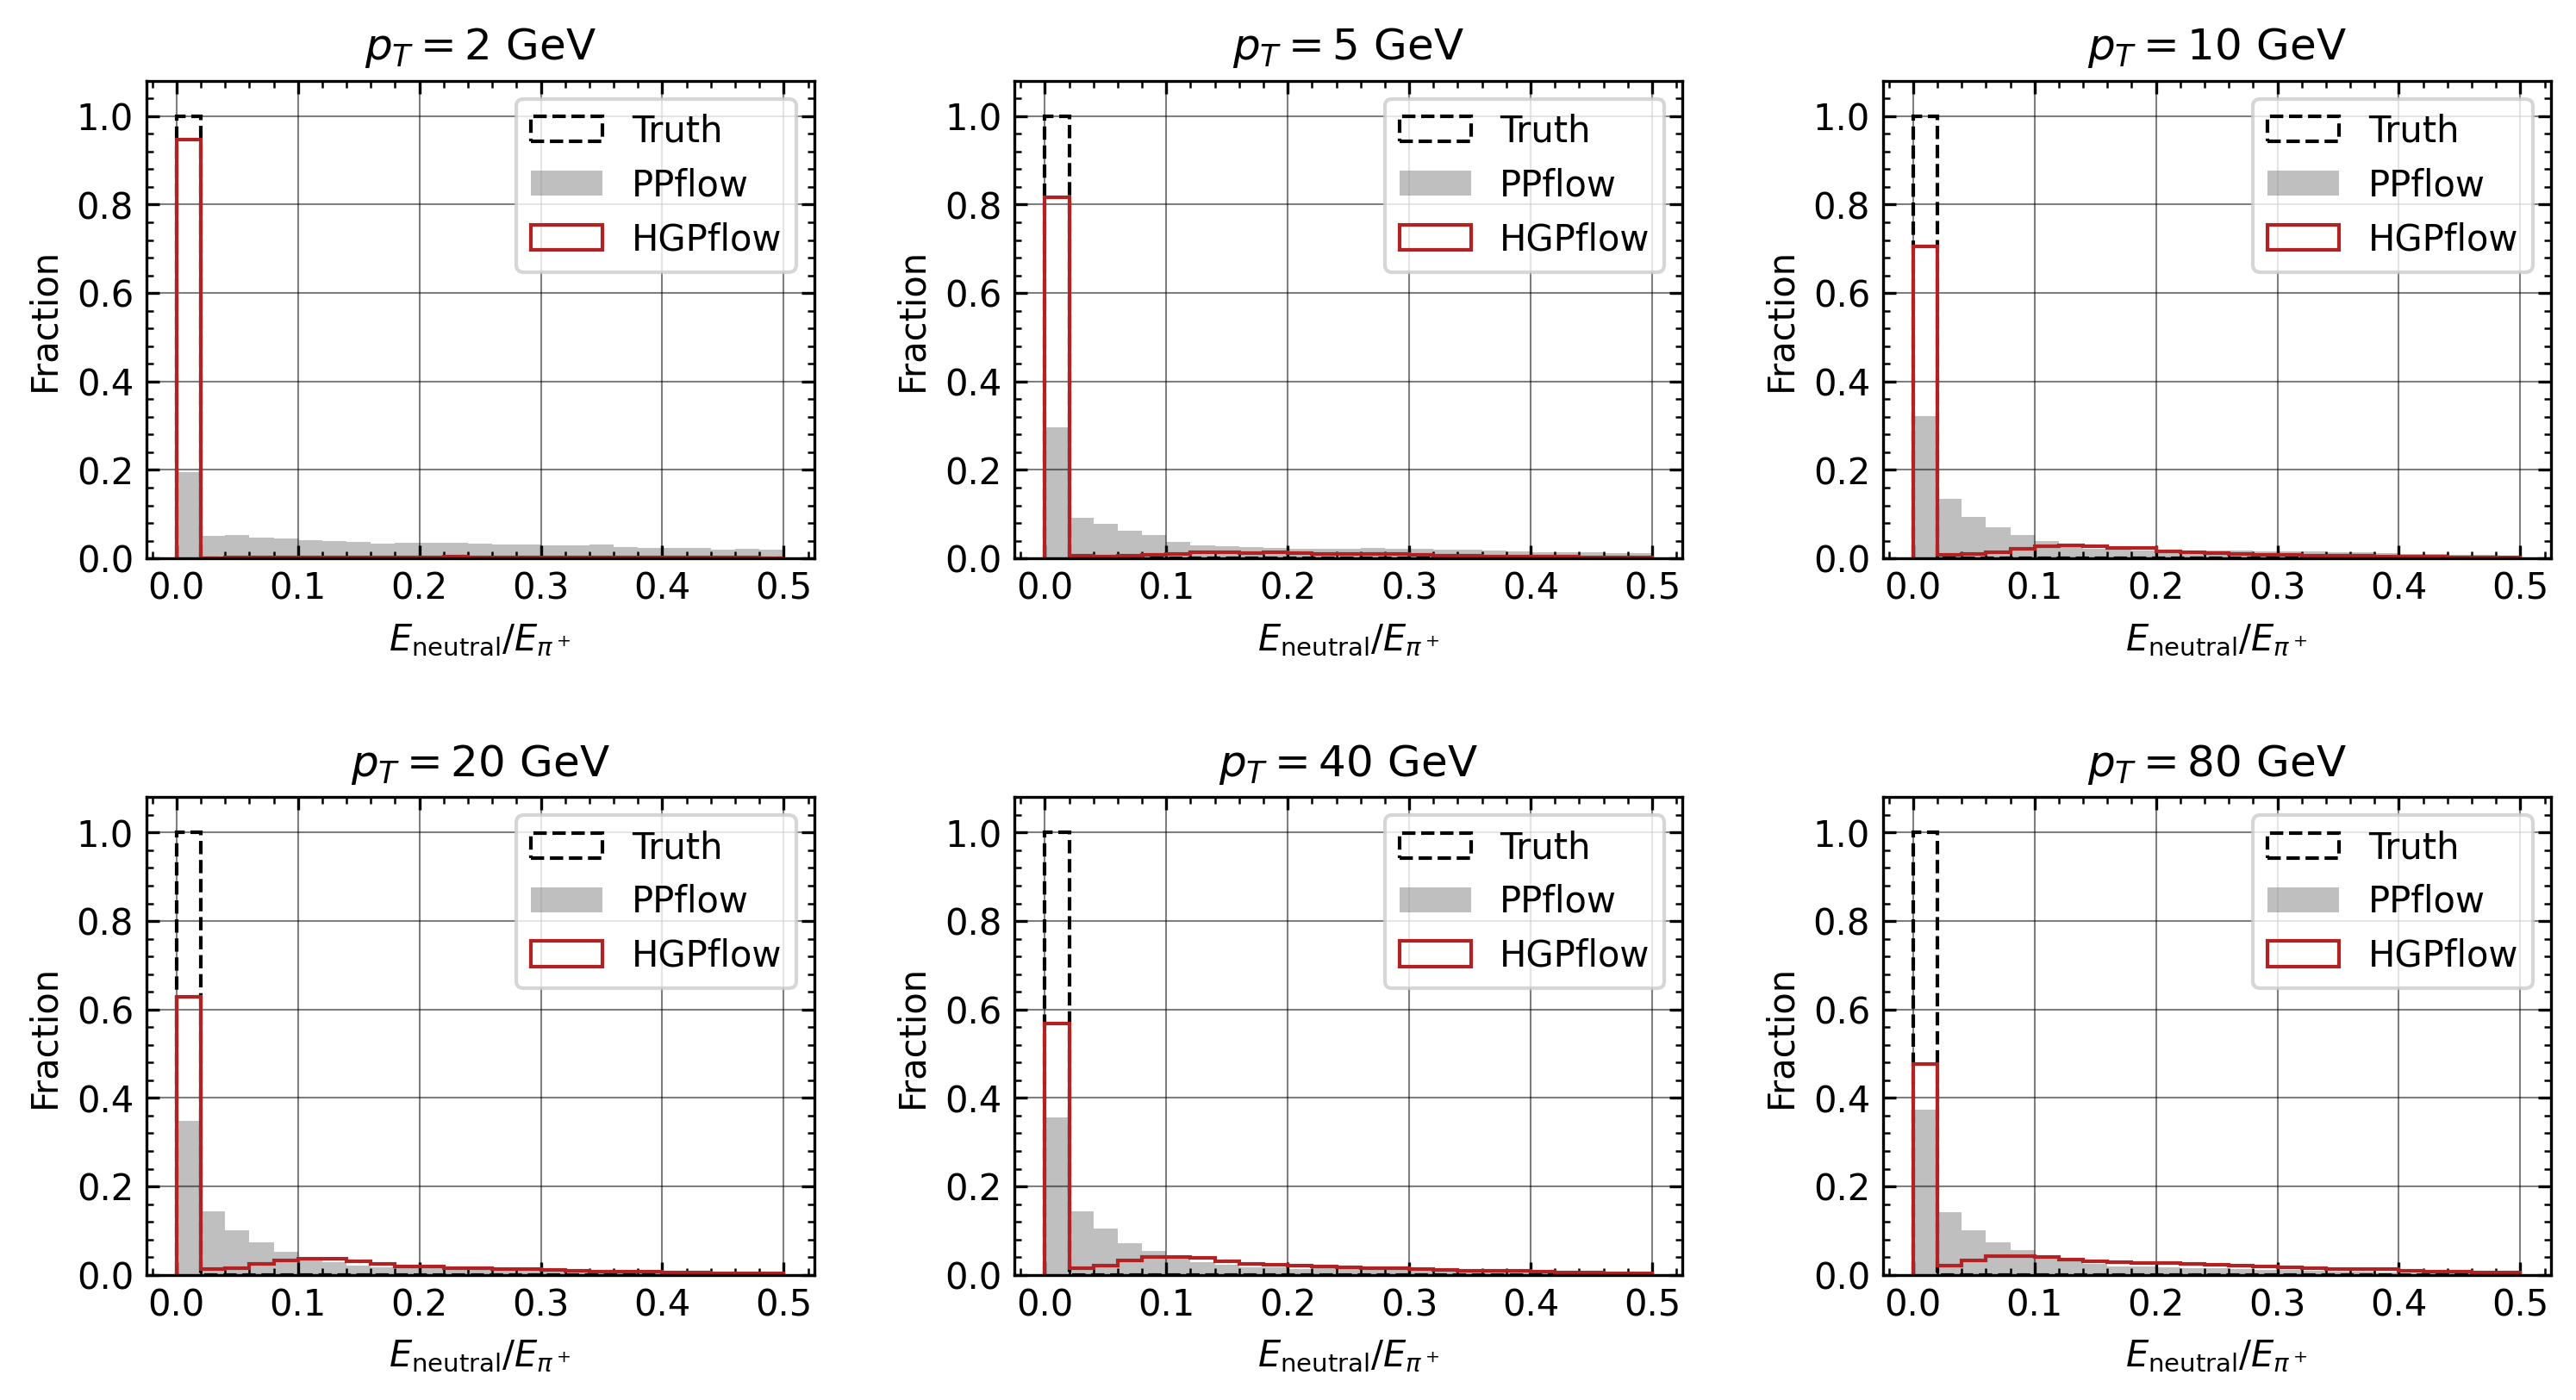

In [51]:
from hgpflow_v2.performance.plot_helper_event import plot_event_neut_energy_res

e_bins = np.array([0, 5, 10, 20, 40, 60, 80]) #, 100, 120, 140, 160, 180, 200, 250, 300, 400, 500, 1000])
fig = plot_event_neut_energy_res(ev_eres_dict=neut_energy_res_dict)

## ttbar

In [52]:
truth_path = '/pscratch/sd/a/agolub/hgpflow_paper_files/ttbar.root'
pred_path = '/pscratch/sd/a/agolub/hgpflow_runs/hgpflow_v2/largeqqbartraining4nodev1epoch25/inference/ttbar/*.root'
perf_obj_ttbar = PerformanceCOCOA(truth_path, pred_path, ind_threshold=0.5, topo=False)

Computing HGPFlow mass...: 100%|██████████| 22500/22500 [00:01<00:00, 20233.66it/s]


E, pT will be scaled by 0.001


Applying fiducial cuts...: 100%|██████████| 22500/22500 [00:00<00:00, 43170.32it/s]
/global/u1/a/agolub/HGPflow/hgpflow_v2/performance/reader.py:56: RuntimeWarning: invalid value encountered in sqrt
  5.:2  # muon
/global/u1/a/agolub/HGPflow/hgpflow_v2/performance/reader.py:62: RuntimeWarning: invalid value encountered in sqrt
  mlpf_class  = tree['pred_cl'].array(library='np')


common event count: 22500


Filtering and reordering HGPFlow...: 100%|██████████| 12/12 [00:00<00:00, 1071.11it/s]


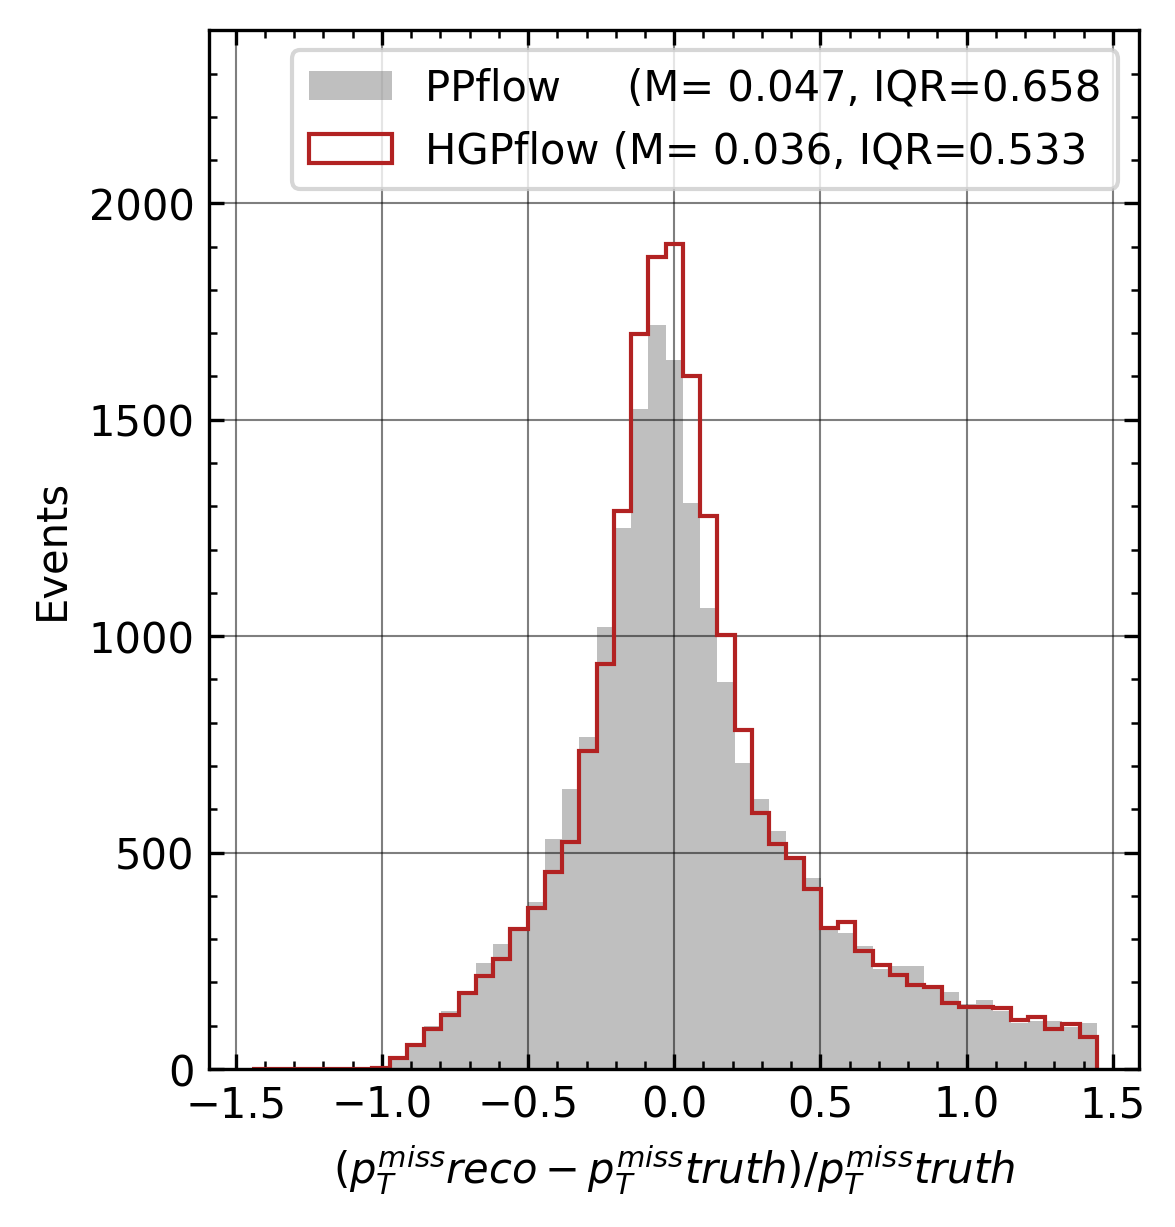

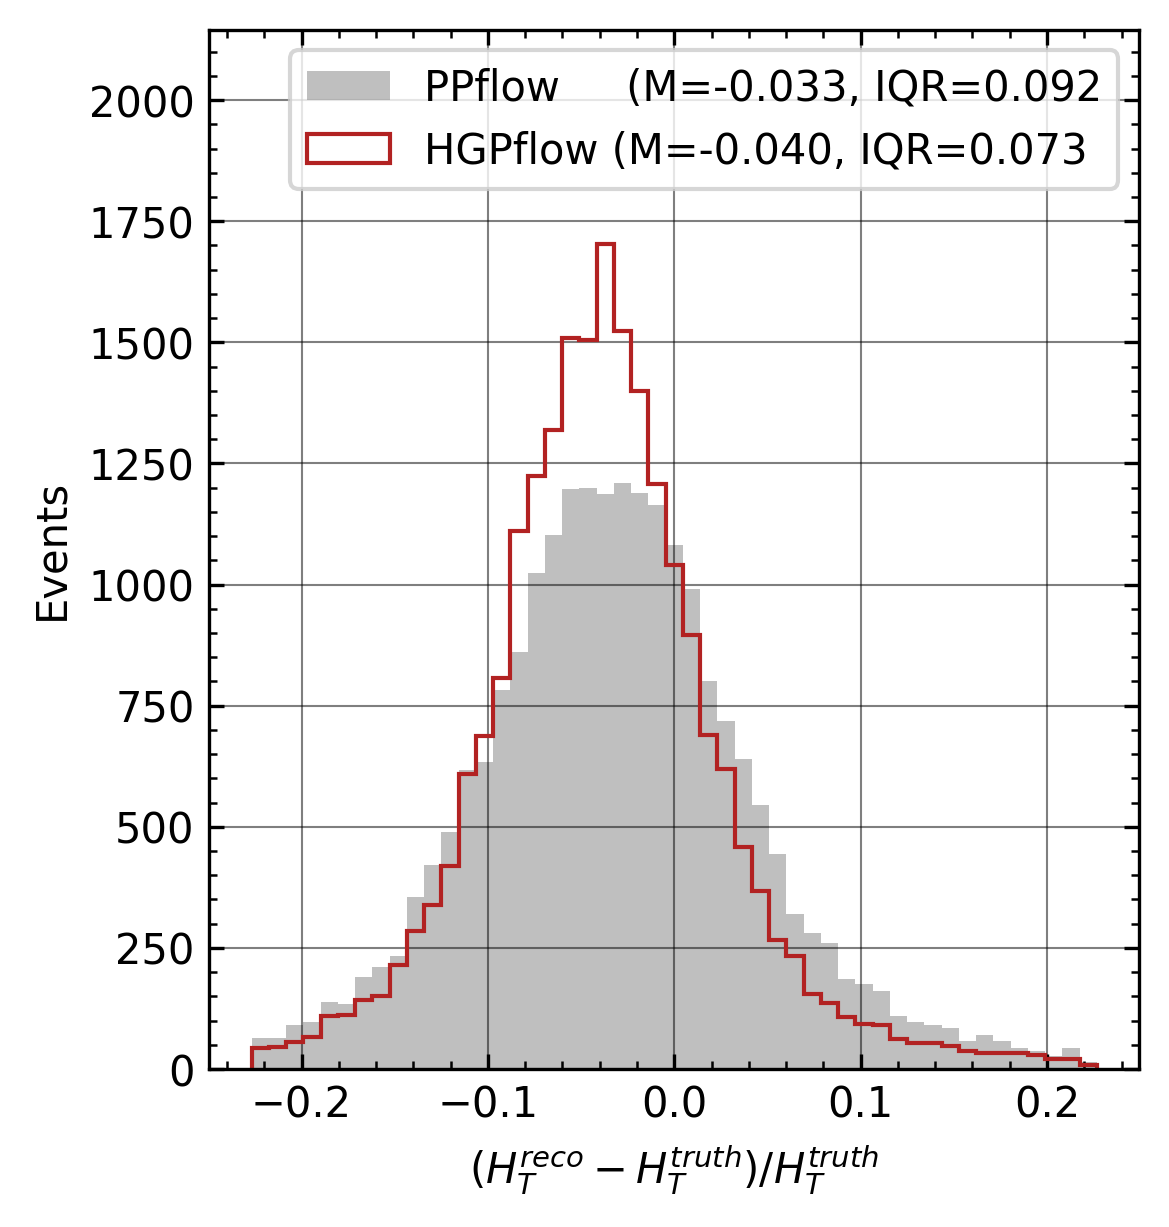

In [53]:
from hgpflow_v2.performance.plot_helper_event import plot_met_res_and_ht_res

met_res_and_ht_res_input_dict_ttbar = {
    'ppflow': [perf_obj_ttbar.truth_dict['pflow_pt'], perf_obj_ttbar.truth_dict['pflow_phi']],
    'hgpflow': [perf_obj_ttbar.hgpflow_dict['hgpflow_pt'], perf_obj_ttbar.hgpflow_dict['hgpflow_phi']],
}
fig_met, fig_ht = plot_met_res_and_ht_res(perf_obj_ttbar.truth_dict['particle_pt'], perf_obj_ttbar.truth_dict['particle_phi'], met_res_and_ht_res_input_dict_ttbar)